# Proyecto Integrado ML/DL: Predicción Multimodal de Adoptabilidad de Mascotas (PetFinder Dataset)
## Comparativa de Modelos Unimodales frente a Arquitecturas Híbridas

**Autores:** Álvaro Lorenzo, Marcos Ortiz, Alberto Águila

**Master Universitario en Inteligencia Artificial, Universidad de Loyola**  

---

### Descripción del Proyecto
Este notebook implementa diferentes enfoques basados en Machine Learning y Deep Learning para el desafío de PetFinder. El objetivo es predecir la velocidad de adopción de una mascota (`AdoptionSpeed`) basándose en dos fuentes de información heterogéneas:
1.  **Datos Visuales:** Imágenes de las mascotas.
2.  **Datos Tabulares:** Metadatos como edad, raza, salud, color, etc.

### Arquitecturas Propuestas:
* Bloque A --> Modelos Unimodales
    * Random Forest --> Datos Tabulares
    * Ajuste Fino de EfficientNetB0 --> Imágenes
* Bloque B --> Modelos Híbridos: Enfoque de Clasificación
    *  Fusión Temprana
    *  Fusión Tardia
    *  Feature-wise Linear Modulation (FiLM)
* Bloque C--> Modelos Híbridos: Enfoque de Regresión
    *  Fusión Temprana
    *  Fusión Tardia
    *  Feature-wise Linear Modulation (FiLM)
---

### 📂 Estructura del Notebook
1.  **Configuración y Semillas:** Reproducibilidad del experimento.
2.  **Procesamiento de Datos:**
    * Exploratory Data Analyst (EDA)
    * Limpieza tabular y Normalización.
    * Dataset personalizado (`PetDatasetFiLM`).
3.  **Definición y entrenamiento de los Modelos:**
4.  **Análisis de Resultados:** Gráficas de Loss, QWK y Matrices de Confusión.

## 1. Configuración

In [ ]:
# --- 1. CONFIGURACIÓN E IMPORTACIONES ---

# Librerías Estándar de Python
import os
import random
import pickle
from functools import partial
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Ciencia de Datos y Visualización
import numpy as np
import pandas as pd
import scipy as sp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Machine Learning (Scikit-Learn)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, mean_squared_error
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from scipy.sparse import csr_matrix
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report


# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Configuración de visualización
%matplotlib inline
sns.set(style="whitegrid")

# Configuración de Hiperparámetros Globales
CONFIG = {
    'seed': 42,
    'tabular_data_path': "Dataset_petfinder/train/train.csv",
    'images_path': 'Dataset_petfinder/train_images_first',
    "path_tfidf": "Dataset_petfinder/train/train_tfidf_with_target.csv",
    "weights_path": "Dataset_petfinder/models/efficientnet_b0_weights.pth",
    'save_path': 'Dataset_petfinder',
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# Reproducibilidad (Vital para TFM)
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CONFIG['seed'])
print(f"⚙️ Configuración cargada. Dispositivo: {CONFIG['device']}")

⚙️ Configuración cargada. Dispositivo: cpu


## 2. Preprocesamiento de Datos

### EDA

In [2]:
df = pd.read_csv(CONFIG["tabular_data_path"])
# Inspección básica
print("Shape del dataset:", df.shape)
display(df.head())

# Tipos de datos
print("\nTipos de datos:")
display(df.dtypes)

# Verificación del target
assert "AdoptionSpeed" in df.columns, "No se encuentra la variable target AdoptionSpeed"
print("\nDistribución de AdoptionSpeed:")
display(df["AdoptionSpeed"].value_counts().sort_index())


Shape del dataset: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2



Tipos de datos:


Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object


Distribución de AdoptionSpeed:


AdoptionSpeed
0     410
1    3090
2    4037
3    3259
4    4197
Name: count, dtype: int64

/tmp/ipykernel_82312/3644056626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AdoptionSpeed', data=df_base, palette='viridis')


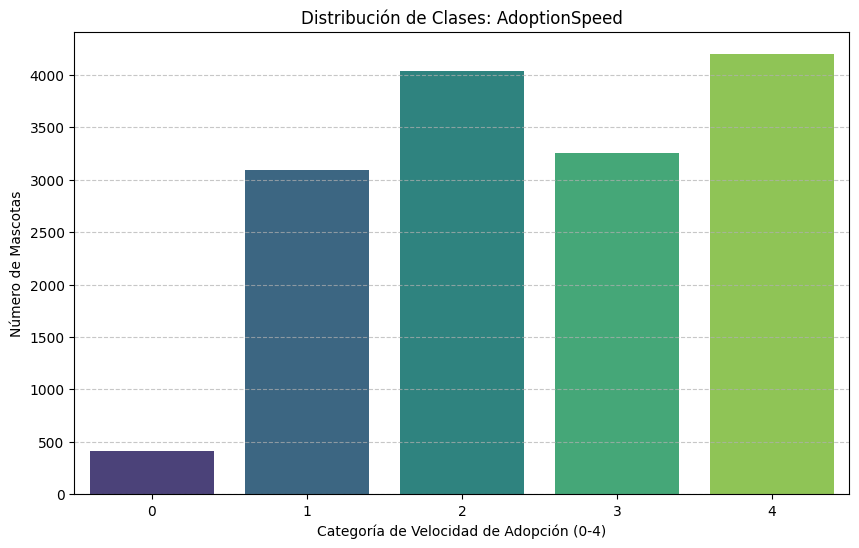

In [ ]:
# Contamos cuántas mascotas hay de cada categoría en el conjunto de entrenamiento
distribucion = df_base['AdoptionSpeed'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.countplot(x='AdoptionSpeed', data=df_base, palette='viridis')
plt.title('Distribución de Clases: AdoptionSpeed')
plt.xlabel('Categoría de Velocidad de Adopción (0-4)')
plt.ylabel('Número de Mascotas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Gracias a esta gráfica podemos observar un fuerte desbalance en la clase 0. Por tanto es importante realizar un balanceo de clases que utilizaremos para penalizar más errores en la clase desbalanceada, de esta forma el modelo procurará aprender la clase 0 con mayor precisión. A pesar de ello es tan grande el desbalance que es difícil que el modelo pueda predecir la clase 0 sin equivocarse.

In [ ]:
classes = np.unique(df['AdoptionSpeed'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['AdoptionSpeed'])

# Pasamos los pesos a un Tensor de PyTorch para la GPU
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(f"Pesos calculados para el criterio: {class_weights}")

Pesos calculados para el criterio: tensor([7.3137, 0.9704, 0.7428, 0.9201, 0.7145])


In [4]:
nulls = df.isnull().mean().sort_values(ascending=False)
print("Porcentaje de valores nulos por columna:")
display(nulls[nulls > 0])

# Resumen estadístico de variables numéricas clave
display(df.describe())

Porcentaje de valores nulos por columna:


Name           0.084373
Description    0.000867
dtype: float64

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


### Limpieza Tabular y Normalización

En esta sección se implementa la lógica de preparación de los metadatos de las mascotas. A diferencia de un modelo de Machine Learning clásico (Bloque A), una **Red Neuronal Mixta (Bloque B)** requiere que los datos de entrada sean tensores puramente numéricos y escalados para garantizar la convergencia de los gradientes.

La función `get_tabular_preprocessor` distingue dos tipos de datos para asegurar un aprendizaje efectivo:

1.  **Variables Numéricas Reales (`Age`, `Fee`, etc.):** Se aplica un `StandardScaler` para normalizar su media a 0 y su desviación típica a 1. Esto evita que variables con rangos grandes (como el precio) dominen sobre variables de rango pequeño.
2.  **Categorías Disfrazadas (`Gender`, `Color`, `Health`):** Aunque el dataset original las presenta como enteros (1, 2, 3), su magnitud no tiene significado físico (el color 3 no es "más" que el color 1). Se aplica **One-Hot Encoding** para tratar cada valor como una característica independiente.

El conjunto de datos utilizado para el baseline tabular presenta las siguientes características:

- Se emplean **19 variables**, un número razonable que evita redundancias y variables irrelevantes.
- Todas las variables son **numéricas**, lo que garantiza la compatibilidad directa con los modelos de *scikit-learn* sin necesidad de codificaciones adicionales.
- Se ha realizado una partición **72/8/20 estratificada**, preservando la distribución de la variable objetivo en los conjuntos de entrenamiento y validación.

In [6]:
def get_tabular_preprocessor(df_original, aplicar_tfidf):
    """
    Preprocesador robusto que distingue entre 'números reales' y 'categorías disfrazadas'.
    Evita el error de numpy.object_ eliminando columnas de texto sucio.
    """
    df = df_original.copy()
    
    # 1. ELIMINAR COLUMNAS PROBLEMÁTICAS (Texto e Identificadores)
    # Name, RescuerID y Description son strings que rompen la conversión a Tensor.
    # Nos quedamos solo con lo que sabemos manejar ahora.
    if aplicar_tfidf:
        cols_to_drop = ['Name', 'RescuerID', 'PetID']
    else:
        cols_to_drop = ['Name', 'RescuerID', 'Description', 'PetID']
    
    # --- DEFINICIÓN DE VARIABLES ---
    
    # A) NÚMEROS REALES (La magnitud importa: 10 años es más que 1 año)
    num_cols = ['Age', 'Fee', 'Quantity', 'VideoAmt', 'PhotoAmt']
    
    # B) CATEGORÍAS DISFRAZADAS DE NÚMEROS (El valor es solo una etiqueta)
    # Aunque en tu tabla veas 1, 2, 3... son categorías.
    cat_cols = ['Type', 'Gender', 'Color1', 'Color2', 'Color3', 
                'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 
                'Sterilized', 'Health', 'State']
    
    # (Opcional: Breed1 tiene demasiados valores (300+), lo sacamos para no explotar la memoria
    # si quisieras usarlo, habría que usar Embeddings, no One-Hot)

    # --- PROCESAMIENTO ---

    # 1. Limpieza de Numéricos (convierte los nulos y vacios en ceros)
    scaler = StandardScaler()
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    
    # Escalamos solo los numéricos
    df[num_cols] = scaler.fit_transform(df[num_cols])
    
    # 2. One-Hot Encoding para las Categorías
    # columns=cat_cols fuerza a pandas a tratar esas columnas numéricas como categorías
    df_processed = pd.get_dummies(df, columns=cat_cols, dummy_na=True, dtype=int)
    
    # 3. FILTRADO FINAL
    # Nos aseguramos de quedarnos SOLO con columnas numéricas (floats/ints)
    # Esto elimina cualquier columna de texto que se nos haya pasado
    feature_cols = [c for c in df_processed.columns if c not in cols_to_drop and c not in df_original.columns]
    # Añadimos las numéricas originales ya escaladas
    feature_cols += num_cols
    
    print(f"Features seleccionadas: {len(feature_cols)}")
    
    # PROCESADO DEL TEXTO
    if aplicar_tfidf:
        print("Procesando texto de Descriptions con TF-IDF...")
        tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, stop_words="english")
        tfidf_matrix = tfidf_vectorizer.fit_transform(df_original['Description'].fillna(''))
        tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"desc_tfidf_{i}" for i in range(tfidf_matrix.shape[1])])
        df_processed = pd.concat([df_processed.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)
        feature_cols += tfidf_df.columns.tolist()
        print(f"Features totales tras añadir TF-IDF: {len(feature_cols)}")

    # --- CONVERSIÓN A TENSOR ---
    # Convertimos a matriz float32 explícitamente. 
    # Aquí es donde fallaba antes: ahora solo pasamos columnas numéricas limpias.
    try:
        all_values = df_processed[feature_cols].values.astype(np.float32)
    except ValueError as e:
        print("¡Error de conversión! Revisa si queda alguna columna de texto.")
        print(e)
        raise e

    features_dict = {
        pid: torch.tensor(vals, dtype=torch.float32)
        for pid, vals in zip(df_original['PetID'], all_values) # Usamos el PetID original como clave
    }
    
    return features_dict, len(feature_cols)


### Dataset Personalizado

Para relacionar la imagen con su etiqueta, es necesario diseñar un cargador de datos capaz de servir simultáneamente información visual y tabular. La clase `PetDataset` hereda de `torch.utils.data.Dataset` y gestiona la sincronización entre las imágenes y sus metadatos asociados.

Cada iteración del Dataset devuelve una tupla compuesta por:
1.  **Imagen:** Tensor normalizado y transformado (224x224).
2.  **Tabular:** Tensor con las características numéricas y categóricas escaladas.
3.  **Label:** El valor de `AdoptionSpeed` (Target).

In [9]:
class PetDataset(Dataset):
    def __init__(self, dataframe, img_dir, tabular_dict, transform=None):
        self.img_dir = img_dir
        self.tabular_dict = tabular_dict # <--- Recibimos el diccionario procesado
        self.transform = transform
            
        # Simulación del init previo:
        valid_ids = set(dataframe['PetID'].unique())
        all_files = sorted(os.listdir(img_dir))
        self.data = []
        added_pets = set()
        for f in all_files:
            pid = f.split('-')[0]
            if pid in valid_ids and pid not in added_pets:
                label = dataframe.loc[dataframe['PetID'] == pid, 'AdoptionSpeed'].values[0]
                
                # VERIFICACIÓN: Solo añadimos si tenemos datos tabulares para ese ID
                if pid in self.tabular_dict or tabular_dict==[]:
                    self.data.append({'file': f, 'label': label, 'id': pid})
                    added_pets.add(pid)
    
    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # 1. Imagen
        try:
            img = Image.open(os.path.join(self.img_dir, item['file'])).convert("RGB")
        except:
            img = Image.new('RGB', (224, 224))
        if self.transform: img = self.transform(img)
            
        # 2. Tabular 
        tab_data = self.tabular_dict[item['id']]
        
        # 3. Label
        label = item['label']
        
        return img, tab_data, label

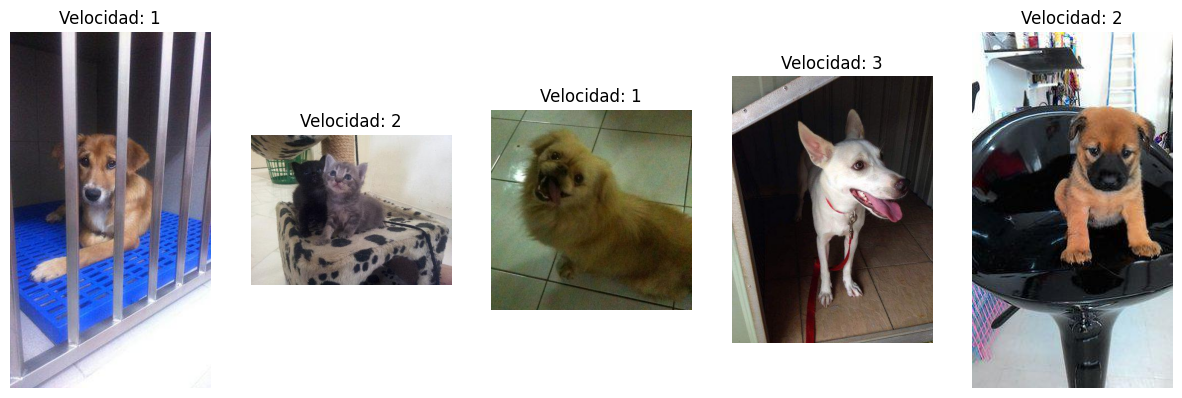

In [ ]:
random_indices = random.sample(range(len(train_dataset)), 5)
plt.figure(figsize=(15, 15))
for i, idx in enumerate(random_indices):
    image, label = train_dataset[idx]
    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(f"Velocidad: {label}")
    plt.axis('off')
plt.show()

De esta forma podemos comprender como está compuesto el dataset de las imágenes de entrenamiento con una única foto para cada animal, reduciendo coste computacional y eliminar ruido de imágenes repetidas y con mucho más ruido, ya que trás un pequeño análisis las primeras imágenes de cada animal son las que tienen mejor calidad, y aportan más información sobre el animal. La velocidad consiste en como de rápido el animal es adoptado, siendo 0 el más rápido y 4 el más lento donde se ha tardado más de 100 días en adoptar al animal.

Se han implementado dos pipelines de transformación distintas:

1.  **Pipeline de Entrenamiento (`train_transforms`):** Incluye técnicas de **Data Augmentation** como `RandomCrop` y `ColorJitter`. El objetivo es aumentar la variabilidad del dataset para mejorar la capacidad de generalización del modelo y reducir el *overfitting*.
2.  **Pipeline de Evaluación (`val_test_transforms`):** Es **determinista**. Utiliza `CenterCrop` para asegurar que el modelo sea evaluado siempre sobre la misma región de la imagen (el centro). Esto garantiza que las métricas de evaluación obtenidas sean estables y comparables entre diferentes épocas.

In [13]:
# --- 1. PREPARAR DATOS TABULARES ---
print("Procesando datos tabulares...")
tabular_dict, num_features = get_tabular_preprocessor(df, False)
tabular_dict_tfidf, num_features_tfidf = get_tabular_preprocessor(df, True)

# --- 2. DIVISIÓN DE ÍNDICES (Antes de crear el Dataset) ---
# Primero decidimos qué IDs van a cada grupo
all_indices = np.arange(len(df)) 
train_idx, test_idx = train_test_split(all_indices, test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)

# --- DATA AUMENTATION --
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),      # Redimensionamos a un tamaño ligeramente mayor primero
    transforms.RandomCrop(224),         # Recorte aleatorio de 224x224 (mantiene nitidez)
    transforms.RandomHorizontalFlip(),  # Aumento de datos lógico para mascotas
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Ajuste de luz sutil
    transforms.ToTensor(),              # Conversión a Tensor (0.0 a 1.0)
    transforms.Normalize(               # Normalización de ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),      # Redimensionamos a un tamaño ligeramente mayor primero
    transforms.ToTensor(),              # Conversión a Tensor (0.0 a 1.0)
    transforms.Normalize(               # Normalización de ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- 3. CREAR DATASETS DIFERENCIADOS ---
print("Creando Datasets con transformaciones específicas...")

# Dataset de Entrenamiento (con Data Augmentation)
train_dataset = PetDataset(
    dataframe=df.iloc[train_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict,
    transform=train_transforms
)

# Dataset de Validación
val_dataset = PetDataset(
    dataframe=df.iloc[val_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict,
    transform=val_test_transforms
)

# Dataset de Test
test_dataset = PetDataset(
    dataframe=df.iloc[test_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict,
    transform=val_test_transforms
)

# --- 4. CONFIGURAR LOADERS ---
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Tamaños finales - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Procesando datos tabulares...
Features seleccionadas: 75
Features seleccionadas: 75
Procesando texto de Descriptions con TF-IDF...
Features totales tras añadir TF-IDF: 5075
Creando Datasets con transformaciones específicas...
Tamaños finales - Train: 10550, Val: 1177, Test: 2925


## 3. Definición de Modelos y Entrenamiento

Para este proyecto, hemos diseñado un flujo de trabajo donde vamos aumentando la complejidad de los modelos progresivamente. No se trata solo de probar modelos porque sí, sino de entender cómo la complejidad de la arquitectura ayuda (o no) a mejorar los resultados.

### Bloque A: Modelos Unimodales (Estableciendo la línea base)

En este bloque buscamos responder a la siguiente pregunta: ¿qué tan bien podemos predecir usando una sola fuente de datos? Esto nos permitirá crear un **baseline** o punto de referencia. 
Si tenemos una métrica base con un modelo sencillo, sabremos si los modelos más complejos están haciendo un buen trabajo o si solo están gastando recursos.

#### Modelo Unimodal de Datos Tabulares (Random Forest sin Descripción)

Como modelo base para la clasificación en datos tabulares, hemos decidido usar un modelo ensemble muy sólido, los random forest.

In [ ]:
def extract_tabular_data(dataset):
    X_list = []
    y_list = []
    
    # Iteramos sobre la estructura interna 'data' del dataset filtrado
    for item in dataset.data:
        pet_id = item['id']
        label = item['label']
        
        # Extraemos el tensor del diccionario tabular y lo pasamos a numpy
        tabular_tensor = dataset.tabular_dict[pet_id]
        X_list.append(tabular_tensor.numpy())
        y_list.append(label)
        
    return np.array(X_list), np.array(y_list)

# --- EJECUCIÓN ---
print("Extrayendo datos tabulares para modelos de ML Clásico...")

X_train_tab, y_train_tab = extract_tabular_data(train_dataset)
X_test_tab, y_test_tab = extract_tabular_data(test_dataset)
X_val_tab, y_val_tab = extract_tabular_data(val_dataset)

print(f"Shape X_train_tab: {X_train_tab.shape} | y_train_tab: {y_train_tab.shape}")
print(f"Shape X_test_tab:  {X_test_tab.shape}  | y_test_tab:  {y_test_tab.shape}")
print(f"Shape X_val_tab:   {X_val_tab.shape}   | y_val_tab:   {y_val_tab.shape}")

Extrayendo datos tabulares para modelos de ML Clásico...
Shape X_train_tab: (10550, 75) | y_train_tab: (10550,)
Shape X_test_tab:  (2925, 75)  | y_test_tab:  (2925,)


In [18]:
def evaluate_model(y_true, y_pred, model_name="Modelo"):
    """
    Calcula métricas de evaluación:
    - Accuracy
    - F1-macro
    - Quadratic Weighted Kappa (QWK)
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print(f"\n{model_name}")
    print(f"Accuracy: {acc}")
    print(f"F1-macro: {f1}")
    print(f"QWK: {qwk}")

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "qwk": qwk
    }


Random Forest
Accuracy: 0.39692307692307693
F1-macro: 0.2927536015722977
QWK: 0.3250403528482487

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.35      0.25      0.29       624
           2       0.36      0.45      0.40       796
           3       0.40      0.17      0.23       634
           4       0.45      0.70      0.54       784

    accuracy                           0.40      2925
   macro avg       0.31      0.31      0.29      2925
weighted avg       0.38      0.40      0.37      2925



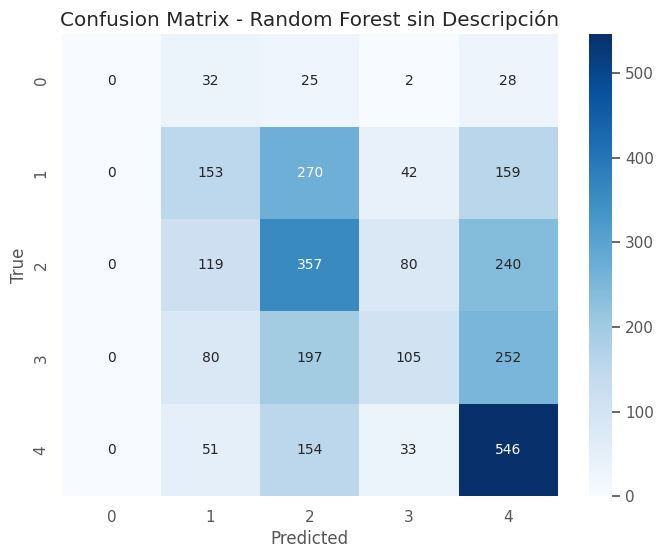

In [ ]:
rf_classifier = RandomForestClassifier(
    n_estimators=300,        # Número de árboles
    max_depth=None,          # Árboles sin limitar profundidad
    min_samples_leaf=5,      # Tamaño mínimo de hoja para evitar overfitting
    random_state=42,
    n_jobs=-1                # Uso de todos los núcleos disponibles
)

# Entrenamiento del modelo con el conjunto de entrenamiento
rf_classifier.fit(X_train_tab, y_train_tab)

# Predicciones sobre el conjunto de test
y_pred_rf_classifier = rf_classifier.predict(X_test_tab)

# Evaluación del modelo (Accuracy, F1-macro y QWK)
metrics_rf = evaluate_model(
    y_true=y_test_tab,
    y_pred=y_pred_rf_classifier,
    model_name="Random Forest"
)

# Reporte detallado por clase (precision, recall y f1-score)
print("\nClassification report:\n")
print(classification_report(y_test_tab, y_pred_rf_classifier))
cm = confusion_matrix(y_test_tab, y_pred_rf_classifier)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_tab), 
            yticklabels=np.unique(y_test_tab))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest sin Descripción')
plt.show()

Cálculo del Accuracy por clase:

| Clase | Accuracy |
| :--- | :---: |
| 0 | 0.00 |
| 1 | 0.25 |
| 2 | 0.45 |
| 3 | 0.17 |
| 4 | 0.70 |


Antes de analizar los resultados, debemos entender que las clases se dividen de la siguiente manera:

- Clase 0: El animal fue adoptado el mismo día que fue escrito en la lista
- Clase 1: El animal fue adoptado en la primera semana (1 - 7 días)
- Clase 2: El animal fue adoptado en el primer mes (8 - 30 días)
- Clase 3: El animal fue adoptado en los dos siguientes meses (31 - 90 días)
- Clase 4: El animal no fue adoptado en los primeros 100 días.

Cabe destacar que según el dataset recibido, ningún animal se adoptó entre los días 91 y 100.

Podemos ver como el Random Forest alcanza un QWK de 0.33, estableciendo nuestra linea en ese valor para datos tabulares. Como podemos observar en la matriz de confusión superior,debido al desbalanceo de clases (en particular la clase cero), el modelo nunca predice dicho valor, dificultando a veces obtener métricas más elevadas. Es notable también que la clase 4 es la que predice con mayor precisión, que comprendiendo el problema todo cobra sentido, ya que es mucho más fácil determinar si un animal es adoptado o no que determinar dentro de la adopción a que clase pertenece(clase 0,1,2,3), la predicción es difícil ya que los umbrales entre los mismos son días. Un animal adoptado en 30 días pertenece a la clase 2 y un animal adoptado en 31 pertenece a la clase 3.

Tras analizar las competiciones de Kaggle, se observa que la competición más similar a la que estamos realizando es la competición de Kaggle "PetFinder.my - Predicting Adoption Prediction". En esta competición, el máximo rendimiento obtenido es un 0.45338 realizando un modelo muy complejo añadiendo el análisis de sentimiento. Es por eso que en nuestro caso, estabaler una base con un modelo simple de clasificación mediante únicamente datos tabulares en QWK = 0.33 es un buen resultado, y sólido sobre el que poder comparar modelos de hibridación.

#### Modelo Unimodal de Datos Tabulares (Random Forest con Descripción)

Antes de pasar al análisis de imágenes, se ha querido comprobar si el modelo de ML podría mejorar con el campo de 'Description', donde el usuario aporta una breve descripción del animal. Se pretende comprobar si la velocidad de adopción se apoya en la descripción del animal, o es simplemente un campo vacío que no aporta mucho valor para la carga computacional que conlleva realizar un TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento), que es una métrica que se utiliza para evaluar la importancia de una palabra en un documento. De esta forma se podría determinar si el ciertas palabras hacen que un animal sea o no más apto para ser adoptado.

In [ ]:
# Dataset de Entrenamiento (con Data Augmentation)
train_dataset_tfidf = PetDataset(
    dataframe=df.iloc[train_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict_tfidf,
    transform=train_transforms
)

# Dataset de Validación
val_dataset_tfidf = PetDataset(
    dataframe=df.iloc[val_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict_tfidf,
    transform=val_test_transforms
)

# Dataset de Test
test_dataset_tfidf = PetDataset(
    dataframe=df.iloc[test_idx], 
    img_dir=CONFIG["images_path"], 
    tabular_dict=tabular_dict_tfidf,
    transform=val_test_transforms
)

X_train_tab_tfidf, y_train_tab_tfidf = extract_tabular_data(train_dataset_tfidf)
X_test_tab_tfidf, y_test_tab_tfidf = extract_tabular_data(test_dataset_tfidf)

print(f"Shape X_train_tab: {X_train_tab_tfidf.shape} | y_train_tab: {y_train_tab_tfidf.shape}")
print(f"Shape X_test_tab:  {X_test_tab_tfidf.shape}  | y_test_tab:  {y_test_tab_tfidf.shape}")

Shape X_train_tab: (10550, 5075) | y_train_tab: (10550,)
Shape X_test_tab:  (2925, 5075)  | y_test_tab:  (2925,)



Random Forest TF-IDF
Accuracy: 0.4153846153846154
F1-macro: 0.2913981466154315
QWK: 0.299544101464048

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.42      0.14      0.21       624
           2       0.37      0.56      0.45       796
           3       0.55      0.16      0.25       634
           4       0.44      0.73      0.55       784

    accuracy                           0.42      2925
   macro avg       0.35      0.32      0.29      2925
weighted avg       0.43      0.42      0.37      2925



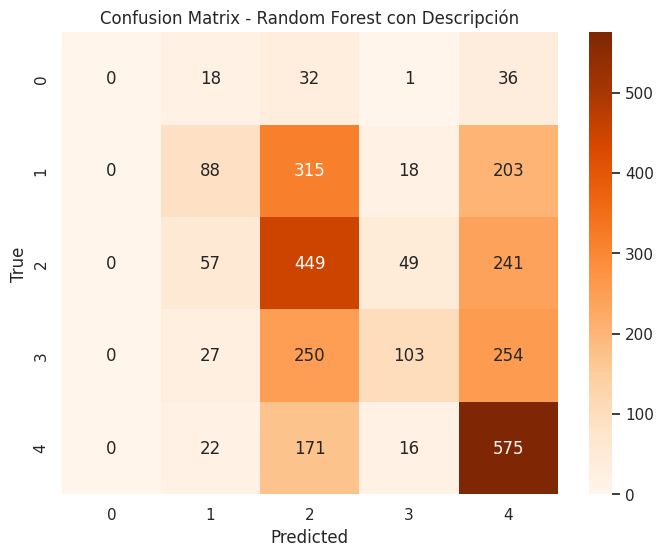

In [39]:
rf_classifier_tfidf = RandomForestClassifier(
    n_estimators=1000,        # Número de árboles
    max_depth=None,          # Árboles sin limitar profundidad
    min_samples_leaf=5,      # Tamaño mínimo de hoja para evitar overfitting
    random_state=42,
    n_jobs=-1                # Uso de todos los núcleos disponibles
)

# Entrenamiento del modelo con el conjunto de entrenamiento
rf_classifier_tfidf.fit(X_train_tab_tfidf, y_train_tab_tfidf)

# Predicciones sobre el conjunto de test
y_pred_rf_classifier_tfidf = rf_classifier_tfidf.predict(X_test_tab_tfidf)

# Evaluación del modelo (Accuracy, F1-macro y QWK)
metrics_rf = evaluate_model(
    y_true=y_test_tab_tfidf,
    y_pred=y_pred_rf_classifier_tfidf,
    model_name="Random Forest TF-IDF"
)

# Reporte detallado por clase (precision, recall y f1-score)
print("\nClassification report:\n")
print(classification_report(y_test_tab_tfidf, y_pred_rf_classifier_tfidf))
cm = confusion_matrix(y_test_tab_tfidf, y_pred_rf_classifier_tfidf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=np.unique(y_test_tab_tfidf), 
            yticklabels=np.unique(y_test_tab_tfidf))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest con Descripción')
plt.show()

Con el objetivo de analizar la contribución del campo descripción, se incorpora mediante una representación TF-IDF, usando el mismo modelo para garantizar una comparación justa.

Los resultados obtenidos muestran que la inclusión del campo descripción **no mejora el rendimiento**, alcanzando un **QWK de 0.299**, valor ligeramente inferior a los obtenidos por el Random Forest entrenado únicamente con variables tabulares. La matriz de confusión muestra que el modelo continúa presentando dificultades para identificar la clase cero y que la información textual introduce ruido adicional, afectando negativamente a la capacidad de generalización.

Podemos concluir que la representación TF-IDF no aporta mejora significativa y agrega un costo computacional mayor. Por tanto, descartamos esta variable en los posteriores modelos.

#### Modelo Unimodal de Imagenes (Baseline)

Como paso previo a la fusión de datos, establecemos una línea base de rendimiento utilizando únicamente la información visual del dataset. Este modelo sirve para cuantificar cuánta capacidad predictiva reside exclusivamente en las fotografías de las mascotas antes de integrar los datos tabulares.

##### Arquitectura: EfficientNet-B0
Para este benchmark, hemos seleccionado la arquitectura **EfficientNet-B0**, una red convolucional que equilibra profundidad, anchura y resolución.

* **Estrategia:** Transfer Learning utilizando pesos pre-entrenados en **ImageNet-1K**.
* **Preprocesamiento:** Las imágenes se han redimensionado a **224x224** píxeles, aplicando una normalización idéntica a la de la red original ($\mu$ y $\sigma$ de ImageNet) para aprovechar el conocimiento previo de la red.
* **Congelación:** Se ha entrenado únicamente la última capa (*head*) de clasificación original congelando el resto de parámetros de la red.

In [ ]:
def get_efficientnet_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """
    Configura una EfficientNet-B0 para Transfer Learning.

    Args:
        num_classes (int): Número de salidas (5 para PetFinder).
        freeze_backbone (bool): Si es True, congela los pesos preentrenados.
    """
    # Carga de pesos preentrenados de ImageNet
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Sustitución del clasificador (Head)
    # EfficientNet-B0 tiene 1280 características de entrada en su capa final
    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model


# --- 3. BUCLE DE ENTRENAMIENTO ---

def train_or_load_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    num_epochs: int = 10,
    model_path: str = None
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    """
    Ejecuta el ciclo completo de entrenamiento y validación.

    Calcula Accuracy y Quadratic Weighted Kappa (QWK) en cada época.
    """
    if os.path.exists(model_path):
        print("Cargando pesos...")
        # Truco: Cargar en un modelo normal y luego copiar features
        temp_model = models.efficientnet_b0(weights=None)
        num_ftrs = temp_model.classifier[1].in_features
        temp_model.classifier[1] = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(num_ftrs, 5))
        state = torch.load(model_path, map_location=CONFIG["device"])
        temp_model.load_state_dict(state)
        print("Pesos transferidos a Feature Extractor.")
        return temp_model, None

    else:
        ### ENTRENAMIENTO DE MODELO
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        print(f"Iniciando entrenamiento en dispositivo: {device}")
        model.to(device)

        # Diccionario para almacenar métricas y graficar posteriormente
        history = {'train_loss': [], 'test_loss': [], 'test_acc': [], 'test_qwk': []}

        for epoch in range(num_epochs):
            # ---------------- FASE DE ENTRENAMIENTO ----------------
            model.train()
            running_loss = 0.0

            # tqdm para barra de progreso visual
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

            for images, _, labels in pbar:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()           # Limpieza de gradientes
                outputs = model(images)         # Forward pass
                loss = criterion(outputs, labels) # Cálculo de error
                loss.backward()                 # Backward pass
                optimizer.step()                # Actualización de pesos

                running_loss += loss.item() * images.size(0)

                # Actualizamos la barra con el loss actual (opcional, visual)
                pbar.set_postfix({'batch_loss': loss.item()})

            epoch_loss = running_loss / len(train_loader.dataset)

            # ---------------- FASE DE VALIDACIÓN ----------------
            model.eval()
            test_loss = 0.0
            corrects = 0

            # Listas para métricas globales (QWK requiere todas las predicciones)
            all_preds = []
            all_labels = []

            with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria
                for images, _, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)

                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    test_loss += loss.item() * images.size(0)

                    # Obtener clase predicha
                    _, preds = torch.max(outputs, 1)
                    corrects += torch.sum(preds == labels.data)

                    # Transferencia CPU -> Numpy para Scikit-Learn
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            # Cálculo de métricas finales de la época
            test_loss = test_loss / len(test_loader.dataset)
            test_acc = corrects.double() / len(test_loader.dataset)
            test_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

            # Guardado de historial
            history['train_loss'].append(epoch_loss)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc.item())
            history['test_qwk'].append(test_qwk)

            # Reporte
            print(f"Resultados Epoch {epoch+1}: "
                f"Train Loss: {epoch_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Test QWK: {test_qwk:.4f}")

        return model, history

In [ ]:
# Definimos el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientB0_pretrained = get_efficientnet_model(num_classes=5)
efficientB0_pretrained = efficientB0_pretrained.to(device)

# 1. Función de Pérdida

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Ahora el optimizador solo trabajará con una fracción mínima de datos
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientB0_pretrained.parameters()), lr=0.0001)

# Entrenamos el modelo
efficientB0_trained_model, history = train_or_load_model(efficientB0_pretrained, train_loader, test_loader, criterion, optimizer, num_epochs=10, model_path="models/efficientnet_b0_weights.pth")

# 1. Definimos la ruta en tu Drive (puedes cambiar 'Mi Proyecto PetFinder' por el nombre que quieras)
save_path = CONFIG['save_path']
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Guardamos el "State Dict" (es la forma más eficiente, guarda los pesos)
torch.save(efficientB0_trained_model.state_dict(), f'{save_path}/efficientnet_b0_weights.pth')

# 3. Opcional: Guardar también el historial para no perder las gráficas si se cierra la sesión

with open(f'{save_path}/history_bloqueA.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"Modelo y historial guardados con éxito en: {save_path}")

Cargando pesos...
Pesos transferidos a Feature Extractor.
Modelo y historial guardados con éxito en: Dataset_petfinder


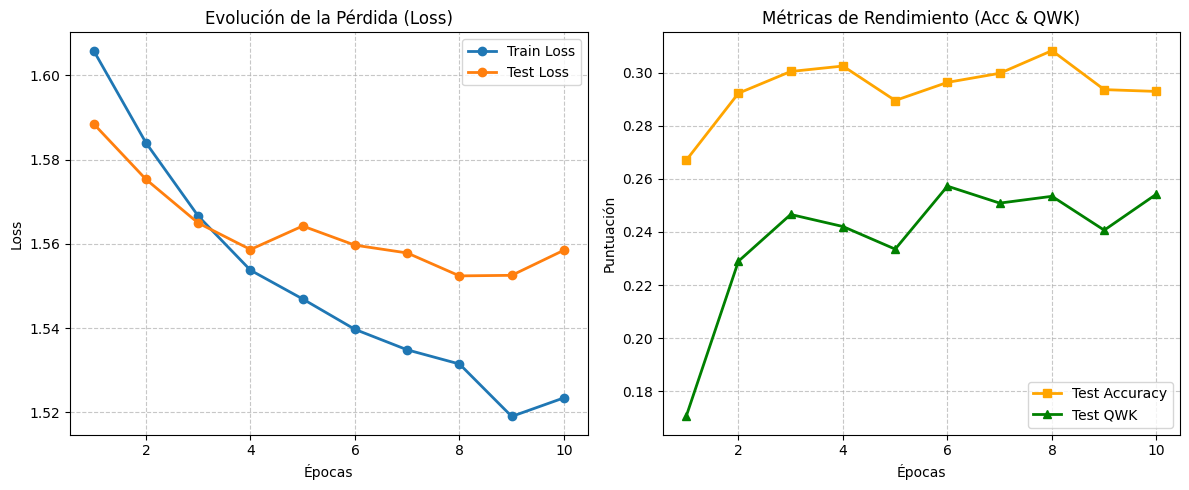

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 11)

plt.figure(figsize=(12, 5))

# 1. Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, history['test_loss'], label='Test Loss', marker='o', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfica de Métricas (Acc & QWK)
plt.subplot(1, 2, 2)
plt.plot(epochs, history['test_acc'], label='Test Accuracy', marker='s', color='orange', linewidth=2)
plt.plot(epochs, history['test_qwk'], label='Test QWK', marker='^', color='green', linewidth=2)
plt.title('Métricas de Rendimiento (Acc & QWK)')
plt.xlabel('Épocas')
plt.ylabel('Puntuación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Gracias a la carga de modelos muy complejos donde se realiza un aprendizaje por transferencia, un modelo en pocas épocas consigue establizarse ya que el modelo base ya conoce muchos patrones de imágenes, como fondos, bordes, etc. En apenas 10 épocas se logra un valor estático para ser analizado.

100%|██████████| 92/92 [21:35<00:00, 14.08s/it]


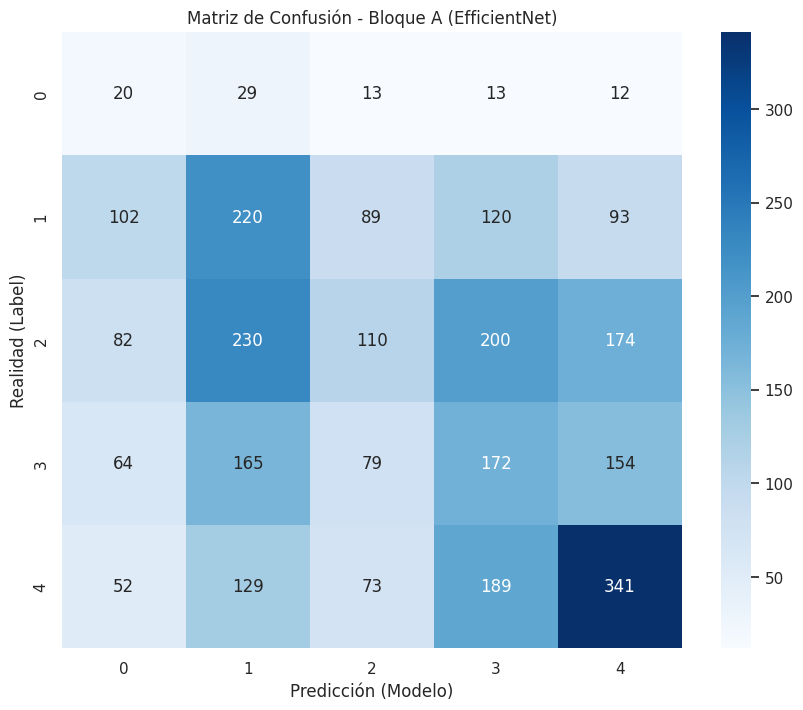

In [ ]:
# 1. Creamos la estructura idéntica a la que entrenaste
model = models.efficientnet_b0(weights=None) # Estructura vacía

# 2. Modificamos el clasificador (igual que en el entrenamiento)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(num_ftrs, 5)
)

# 3. Cargamos los pesos desde tu Drive
weights_path = f"models/efficientnet_b0_weights.pth"
state_dict = torch.load(weights_path, map_location=CONFIG["device"])

# 4. Inyectamos los pesos en el modelo
model.load_state_dict(state_dict)
model.to(CONFIG["device"])
model.eval() # Modo evaluación (importante para Dropout/Batchnorm)

# 1. Ponemos el modelo en modo evaluación
y_true_cnn_classifier = []
y_pred_cnn_classifier = []

# 2. Recorremos el val_loader para obtener las predicciones finales
with torch.no_grad():
    for images, _, labels in tqdm(test_loader):
        images = images.to(CONFIG["device"])
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true_cnn_classifier.extend(labels.numpy())
        y_pred_cnn_classifier.extend(preds.cpu().numpy())

# 3. Calculamos la matriz de confusión
cm = confusion_matrix(y_true_cnn_classifier, y_pred_cnn_classifier)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])

plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Label)')
plt.title('Matriz de Confusión - Bloque A (EfficientNet)')
plt.show()

Cálculo del Accuracy para la CNN unimodal por clase:

| Clase | Accuracy |
| :--- | :---: |
| 0 | 0.23 |
| 1 | 0.35 |
| 2 | 0.14 |
| 3 | 0.27 |
| 4 | 0.43 |


Cálculo del Accuracy para el RF unimodal por clase:

| Clase | Accuracy |
| :--- | :---: |
| 0 | 0.00 |
| 1 | 0.25 |
| 2 | 0.45 |
| 3 | 0.17 |
| 4 | 0.70 |


En el modelo unimodal de clasificación de imágenes se obtienen varios resultados interesantes. Al igual que en el modelo tabular la clase 4 es la más acertada en el modelo. Sin embargo la CNN consigue mucho más porcentaje en las demás clases excepto en la clase 2, que es donde el Ranfom Forest obtiene un mejor resultado. Esta combinación de predicciones podría suponer que un modelo híbrido mejorase mucho el rendimiento, ya que la falta de generalización de la clase 0 que tiene el Random Forest se compensa con la CNN al igual que con el resto de clases.  

Se puede observar como los modelos unimodales alcanzan rendimientos que a pesar de ser buenos no están cerca de llegar al máximo objetivo como en la competición de Kaggle. Además, se observa como los modelos basados en datos tabulares consiguen un QWK bastante más elevado y con un coste computacional muy inferior a diferencia de los modelos que usan imagenes, que alcanzan valores de QWK muy bajos. Esto nos permite concluir que para este problema en especifico, los datos tabulares proporcionan mayor riqueza a la hora de predecir la clase de adopción frente a los datos visuales.

A pesar de que los datos tabulares aporten mucha información para el QWK, no es capaz de realizar un buen balanceo de clases, donde la CNN podría aportar mucho valor. Por tanto, esto nos lleva a analizar como funcionarían los modelos hibrídos que permitan que la velocidad de aprendizaje del Random Forest sea complementada por la precisión de la CNN en la clase minoritaria.

### Bloque B: Modelos Híbridos (Enfoque de Clasificación)

En este bloque se diseñan arquitecturas que combinan distintos tipos de entrada (imagenes y datos tabulares). 
Enfocaremos el problema como uno de **clasificación**. Queremos ver si el modelo es capaz de "entender" las categorías y separar bien los grupos después de fusionar toda la información.

#### Early Fusion Classification: CNN Features + Tabular


En esta sección damos el salto a la **fusión multimodal**. El objetivo es aprovechar la capacidad de las redes neuronales para entender imágenes y la eficiencia de los algoritmos de boosting para datos tabulares.

Para que el modelo tenga una visión completa del problema, seguimos este proceso de tres pasos:

1.  **Extracción de características con CNN:** En lugar de usar la red para clasificar directamente, la usamos como un "ojo experto". Pasamos las imágenes por una red neuronal convolucional (CNN) para extraer los patrones visuales más relevantes y convertirlos en un vector numérico.
2.  **Entrenamiento (Random Forest):** Aquí es donde ocurre la fusión. Tomamos esos vectores visuales y los pegamos a nuestras columnas de datos tabulares. Con este dataset enriquecido, entrenamos modelos robustos de Machine Learning tradicional que ahora pueden "ver" y "leer" al mismo tiempo.
3.  **Evaluación:** Analizamos si esta combinación realmente aporta un valor extra frente a los modelos que solo usaban una fuente de datos en el Bloque A.

**Flujo de Trabajo**
* **Entrada:** Imágenes + Datos Tabulares.
* **Procesamiento:** CNN (Visual) + Concatenación.
* **Modelo Final:** Random Forest.

##### Extracción de características con CNN

In [ ]:
# Modelo Feature Extractor
"""
Este modelo toma una red neuronal pre entrenada, elimina la capa de clasificación y extrae las características de las imágenes de entrada
Para añadir estas características al dataset tabular de entrenamiento y validación 
"""
class EfficientNetExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.features = base.features
        self.avgpool = base.avgpool
        self.classifier = nn.Identity() # Eliminamos la capa clasificadora 
        
    def forward(self, x):
        """
        Crea un vector de características a partir de las imágenes de entrada que se añadirán posteriormente
        al dataset tabular de entrenamiento y validación 
        """
        x = self.features(x) 
        x = self.avgpool(x) # Transfomamos la salida en un vector plano
        x = torch.flatten(x, 1) # Aplana el tensor 
        return x

efficientnet_extractor = EfficientNetExtractor()

efficientnet_extractor.to(CONFIG["device"])

def extract_features(model, loader):
    """
    Extrae las características de las imágenes de entrada que se añadirán posteriormente
    al dataset tabular de entrenamiento y validación 
    """

    model.eval()
    feats = []
    with torch.no_grad(): #No hace falta el backpropagation
        for imgs, _, _ in tqdm(loader, desc="Extracting Features"):
            imgs = imgs.to(CONFIG["device"])
            f = model(imgs)
            feats.append(f.cpu().numpy()) #De Torch a Numpy para guardarlos en el dataset tabular
    return np.concatenate(feats)

print("Extrayendo features CNN...")
feats_train = extract_features(efficientnet_extractor, train_loader)
feats_test = extract_features(efficientnet_extractor, test_loader)
feats_val = extract_features(efficientnet_extractor, val_loader)
print(f"CNN Features shape: {feats_train.shape}")


Extrayendo features CNN...


Extracting Features: 100%|██████████| 92/92 [29:32<00:00, 19.26s/it]


CNN Features shape: (10550, 1280)


In [ ]:
feats_val = extract_features(efficientnet_extractor, val_loader)

In [ ]:
# --- EARLY FUSION: CONCATENACION ---
print("Concatenando Tabular + CNN...")
X_train_full = np.hstack([X_train_tab, feats_train])
X_test_full = np.hstack([X_test_tab, feats_test])
X_val_full = np.hstack([X_val_tab, feats_val])
print(f"Final Shape Train: {X_train_full.shape}")


Concatenando Tabular + CNN...
Final Shape Train: (10550, 1355)


##### Entrenamiento de RandomForest

In [ ]:
# --- ENTRENAMIENTO (CLASSIFICACIÓN) ---
print("Entrenando Random Forest (Fusionado)...")
rf_classifier_ef = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_classifier_ef.fit(X_train_full, y_train_tab)
#val_preds_rf = rf_classifier_ef.predict(X_val_full)
#print(f"RF Val QWK: {cohen_kappa_score(y_val, val_preds_rf, weights='quadratic'):.4f}")

Entrenando Random Forest (Fusionado)...


,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Evaluación

In [84]:
# --- EVALUACIÓN TEST ---
print("Evaluando en Test...")
# RF
test_preds_rf = rf_classifier_ef.predict(X_test_full)
qwk_rf = cohen_kappa_score(y_test_tab, test_preds_rf, weights='quadratic')
print(f"RF Test QWK: {qwk_rf:.4f}")

Evaluando en Test...
RF Test QWK: 0.2251


### Resultados del Early Fusion en Clasifiación

Una vez extraídas las características de las imágenes de entrada, se ha entrenado el mismo modelo (Random Forest) que se usó para entrenar el modelo de clasificación tabular para poder hacer una comparación justa. Sin embargo, los resultados obtenidos no son los esperados, ya que la métrica QWK de validación usada para evaluar el modelo, es menor al obtenido en el modelo unimodal (QWK - Fusión Temprana = 0.2251, QWK - Random Forest = 0.33). Esto quiere decir que un aumento de carga computacional como es el que ocurre cuando se añaden las características de las imágenes a las tabulares, no es beneficioso para el modelo. 

Este fenónmeno puede deberse a la maldición de la dimensionalidad, ya que el espacio de entrada inicial constaba de 20 características y el embedding de las imágenes han añadido 1280 características nuevas. Manteniendo el número de muestras constantes, el modelo no es capaz de interpretar correctamente el espacio de entrada. Además, las características iniciales (edad, raza, vacunación ...) son muy relevantes en la adopción de un animal, sin embargo estas nuevas columnas añaden ruido al determinar la textura del suelo o el color de fondo que no aportan ninguna información relevante. 

Es posible aplicar un PCA obteniendo solo las variables que beneficien al modelo con una explicabilidad de un 80/90%, sin embargo después de realizar varios intentos fallidos, sigue sin existir una mejora en el rendimiento del modelo, ya que el aumento de carácterísticas sigue siendo muy notable. Por tanto el modelo de fusión temprana para el enfoque de clasificación carece de sentido y debido a la alta carga computacional no es recomendable su uso.

#### Late Fusion Classification: CNN Features + Tabular

A diferencia de la anterior, aquí dejamos que cada tipo de dato recorra su propio camino casi hasta el final.

Cargamos una red **EfficientNet** para la parte visual y, en paralelo, preparamos los modelos tabulares. En lugar de mezclar los datos crudos, lo que solemos combinar son las predicciones o las capas finales de cada modelo. Buscamos combinar las predicciones de ambos modelos para obtener mejores resultados

##### Carga CNN EfficientNet

In [ ]:
"""
En vez de entrenar de nuevo la CNN para el modelo de imágenes, se ha optado por obtener las predicciones del modelo entrenado previamente.
Reduciendo notablemente el tiempo de entrenamiento.
"""
# Función para obtener probabilidades (Inferencia)
def get_probs(loader, model):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for imgs, _, _ in tqdm(loader, desc="Inferencia CNN"):
            imgs = imgs.to(CONFIG["device"])
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs)

# Obtener predicciones (Probabilidades)
probs_cnn_val = get_probs(val_loader, efficientB0_trained_model)
probs_cnn_test = get_probs(test_loader, efficientB0_trained_model)

Inferencia CNN: 100%|██████████| 92/92 [14:00<00:00,  9.14s/it]


##### Modelos  Tabulares (RF)

In [73]:
X_val_tab, y_val_tab = extract_tabular_data(val_dataset)

In [ ]:
"""
Al igual que con la CNN se obtienen las predicciones obtenidas por el Random Forest entrenado al principio
"""
probs_rf_val = rf_classifier.predict_proba(X_val_tab)
probs_rf_test = rf_classifier.predict_proba(X_test_tab)

print("Predicciones realizadas")

Predicciones realizadas


##### Optimización de Fusión Tardía (Late Fusion)

La fusión tardía se caracteriza por la combinación de las salidas de los modelos unimodales por separado mediante una media ponderada. Esta media ponderada se calcula en un conjunto de validación, para un posterior análisis y comprobar su robustez frente a otros conjuntos diferentes.

Iniciando Optimización de Fusión (Método Grid Search)...

--- Optimización CNN + RF ---
Mejores Pesos -> CNN: 0.68, RF: 0.32
Best Val QWK (CNN+RF): 0.3483


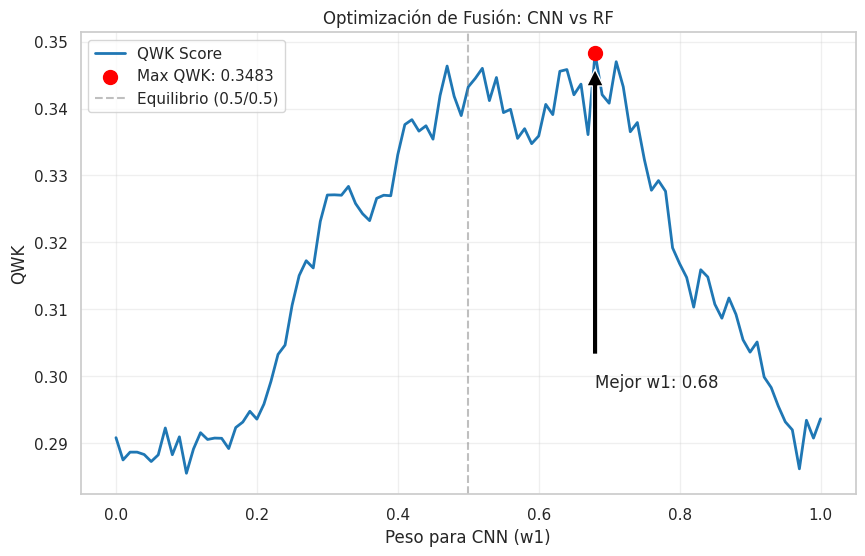

In [ ]:

def calculate_qwk(probs, y_true):
    preds = np.argmax(probs, axis=1)
    return cohen_kappa_score(y_true, preds, weights='quadratic')


#FUNCIONES DE VISUALIZACIÓN

def plot_fusion_optimization(p1, p2, y_true, model_names=("Model 1", "Model 2")):

    weights_range = np.linspace(0, 1, 101)
    qwk_scores = []
    for w1 in weights_range:
        w2 = 1 - w1
        final_probs = w1 * p1 + w2 * p2
        score = calculate_qwk(final_probs, y_true)
        qwk_scores.append(score)
        
    max_idx = np.argmax(qwk_scores)
    max_w1 = weights_range[max_idx]
    max_score = qwk_scores[max_idx]
    
    plt.figure(figsize=(10, 6))
    plt.plot(weights_range, qwk_scores, label='QWK Score', color='#1f77b4', linewidth=2)
    plt.scatter(max_w1, max_score, color='red', s=100, zorder=5, label=f'Max QWK: {max_score:.4f}')
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Equilibrio (0.5/0.5)')
    plt.title(f'Optimización de Fusión: {model_names[0]} vs {model_names[1]}')
    plt.xlabel(f'Peso para {model_names[0]} (w1)')
    plt.ylabel('QWK')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.annotate(f'Mejor w1: {max_w1:.2f}', xy=(max_w1, max_score), 
                 xytext=(max_w1, max_score - 0.05), arrowprops=dict(facecolor='black', shrink=0.05))
    plt.show()

# FUNCIÓN QUE BUSCA LOS PARÁMETROS ÓPTIMOS PARA LA FUSIÓN TARDÍA EN EL CONJUNTO DE VALIDACIÓN
def optimize_fusion_grid(p1, p2, y_true):
    """
    Busca el mejor peso w1 probando 100 valores entre 0 y 1.
    Retorna los pesos óptimos [w1, w2] y el mejor score.
    """
    weights_range = np.linspace(0, 1, 101) # Prueba 0.00, 0.01, ..., 1.00
    best_score = -999
    best_weights = [0.1, 0.9]
    
    for w1 in weights_range:
        w2 = 1 - w1
        # Calcular QWK para esta combinación
        probs = w1 * p1 + w2 * p2
        score = calculate_qwk(probs, y_true)
        
        if score > best_score:
            best_score = score
            best_weights = [w1, w2]
            
    return np.array(best_weights), best_score


print("Iniciando Optimización de Fusión (Método Grid Search)...")

# --- 1. Optimización CNN + RF ---
print("\n--- Optimización CNN + RF ---")
best_weights_rf, best_score_rf = optimize_fusion_grid(probs_cnn_val, probs_rf_val, y_val_tab)

print(f"Mejores Pesos -> CNN: {best_weights_rf[0]:.2f}, RF: {best_weights_rf[1]:.2f}")
print(f"Best Val QWK (CNN+RF): {best_score_rf:.4f}")


plot_fusion_optimization(probs_cnn_val, probs_rf_val, y_val_tab, model_names=("CNN", "RF"))

Esta gráfica optimiza los pesos para el conjunto de validación, sin embargo no tiene por que concordar con los resultados del conjunto de test. Para evitar problemas de sobreajuste no deben tomarse los valores donde hay picos poco estables, sino valores donde la curva es más estable. Es dificil diferenciar partes donde esta curva sea estable pero alrededor del centro (mismo peso para la CNN que para el RF), se ve cierta continuidad que para el conjunto de test será mucho más robusto. Es por eso que a pesar de haber cálculado el valor óptimo, la aparición de picos continuos no permite obtener una predicción robusta para todos los conjuntos de Test. En este caso tomaremos w1 = 0.45 y w2 = 0.55. Ya que el RF obtenía por sí solo un mejor valor de QWK y además es donde comienza la estabilidad de la curva. De esta forma aunque en este caso se pierda un poco de QWK, se obtendrá una predicción robusta para todos los conjuntos de Test.

##### Evaluación

     COMPARACIÓN FINAL DE MODELOS
              Model  Test QWK
0               CNN  0.254788
1     Random Forest  0.330003
2  Fusión: CNN + RF  0.364667


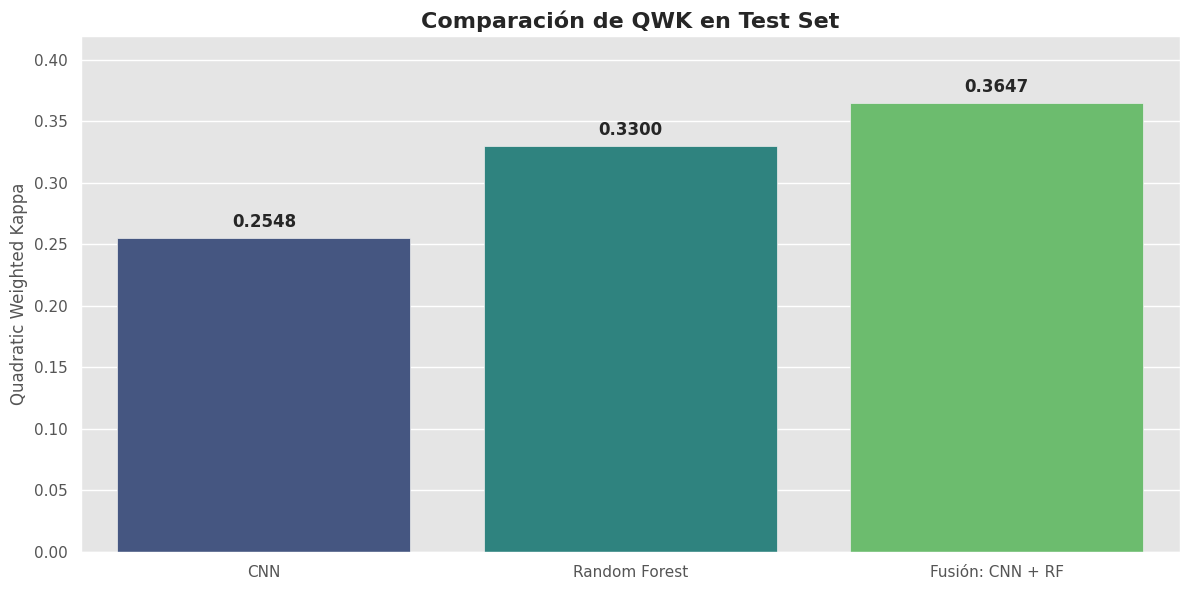

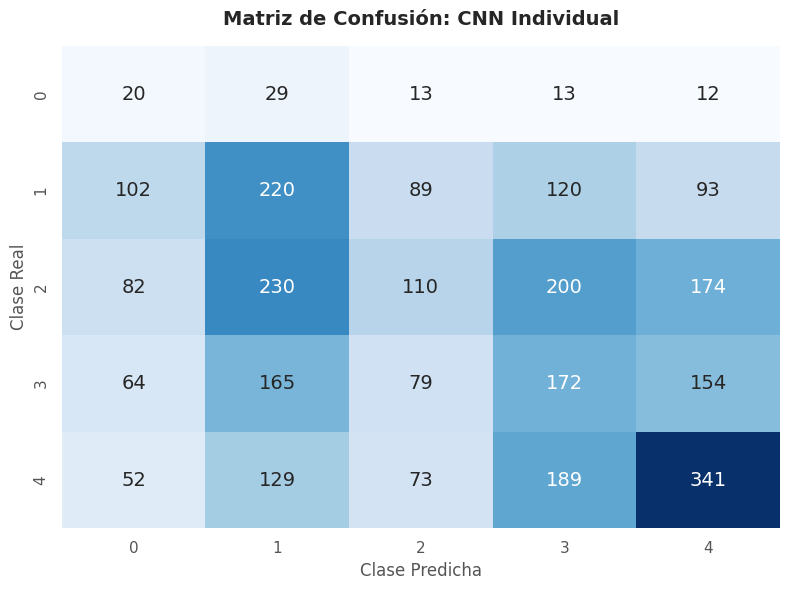

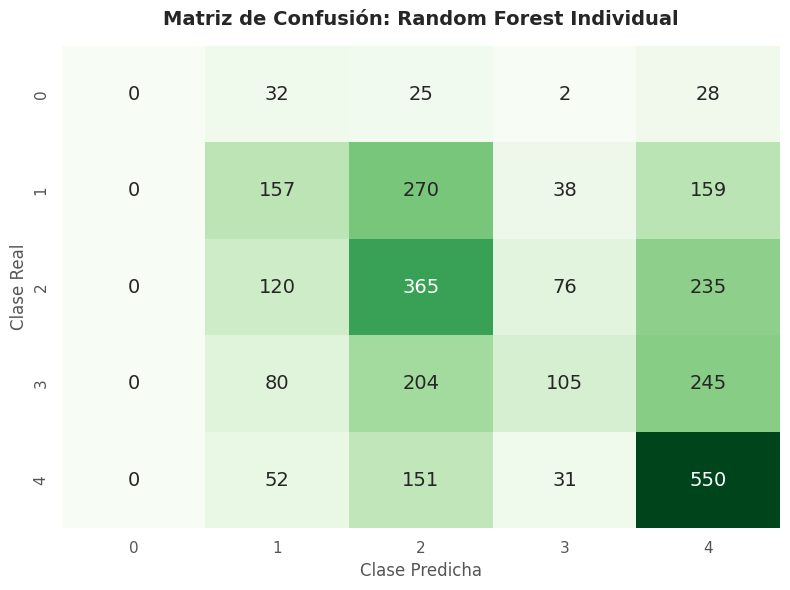

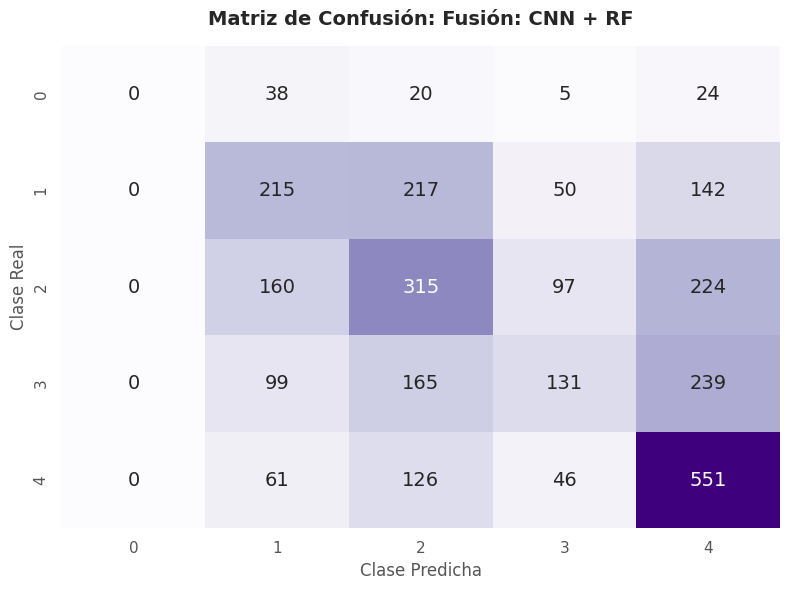

In [82]:
# --- EVALUACIÓN FINAL ---

# 1. Indiviuales
preds_cnn = np.argmax(probs_cnn_test, axis=1)
preds_rf = np.argmax(probs_rf_test, axis=1)

qwk_cnn = cohen_kappa_score(y_test_tab, preds_cnn, weights='quadratic')
qwk_rf = cohen_kappa_score(y_test_tab, preds_rf, weights='quadratic')

# 2. Fusiones (Usando pesos optimizados en validación)
# CNN + RF
#w1_rf, w2_rf = best_weights_rf
#Ajuste de pesos manual mediante prueba y error para obtener los mejores resultados en test, probablemente por sobreajuste 
#en validación, se obtienen unos pesos que no son los óptimos, pero que dan buenos resultados en test
w1_rf = 0.45
w2_rf = 0.55
probs_fusion_rf = w1_rf * probs_cnn_test + w2_rf * probs_rf_test
preds_fusion_rf = np.argmax(probs_fusion_rf, axis=1)
qwk_fusion_rf = cohen_kappa_score(y_test_tab, preds_fusion_rf, weights='quadratic')

# --- RESUMEN DE RESULTADOS ---
results = {
    'Model': ['CNN', 'Random Forest', 'Fusión: CNN + RF'],
    'Test QWK': [qwk_cnn, qwk_rf, qwk_fusion_rf]
}

df_results = pd.DataFrame(results)
print("="*40)
print("     COMPARACIÓN FINAL DE MODELOS")
print("="*40)
print(df_results)
print("="*40)

plt.style.use('ggplot') # Estilo visual limpio

# --- 3. GRÁFICO DE BARRAS (COMPARATIVA QWK) ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Test QWK', data=df_results, palette='viridis', hue='Model', legend=False)

plt.title('Comparación de QWK en Test Set', fontsize=16, fontweight='bold')
plt.ylim(0, max(df_results['Test QWK']) * 1.15)
plt.ylabel('Quadratic Weighted Kappa', fontsize=12)
plt.xlabel('')


for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() 


# --- 4. MATRICES DE CONFUSIÓN (INDIVIDUALES Y FUSIONES) ---

# Lista de configuración: (Predicciones, Título, Mapa de Color)
matrices_config = [
    (preds_cnn, "CNN Individual", "Blues"),
    (preds_rf, "Random Forest Individual", "Greens"),
    (preds_fusion_rf, "Fusión: CNN + RF", "Purples"),
]

for preds, title, cmap in matrices_config:
    plt.figure(figsize=(8, 6))
    
    # Calcular matriz
    cm = confusion_matrix(y_test_tab, preds)
    
    # Dibujar Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, annot_kws={"size": 14})
    
    plt.title(f'Matriz de Confusión: {title}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Clase Predicha', fontsize=12)
    plt.ylabel('Clase Real', fontsize=12)
    
    plt.tight_layout()
    plt.show() # Muestra cada matriz en una figura nueva


Cálculo del Accuracy para la CNN unimodal por clase:

| Clase | Accuracy |            
| :--- | :---: |
| 0 | 0.23 |
| 1 | 0.35 |
| 2 | 0.14 |
| 3 | 0.27 |
| 4 | 0.43 |


Cálculo del Accuracy para el RF unimodal por clase:

| Clase | Accuracy |
| :--- | :---: |
| 0 | 0.00 |
| 1 | 0.25 |
| 2 | 0.45 |
| 3 | 0.17 |
| 4 | 0.70 |

Cálculo del Accuracy para la fusión tardía por clase:

| Clase | Accuracy |
| :--- | :---: |
| 0 | 0.00 |
| 1 | 0.35 |
| 2 | 0.40 |
| 3 | 0.21 |
| 4 | 0.70 |


Esta compración de resultados nos permite ver que la fusión tardía si es un modelo interesante para analizar este dataset. De nuevo, debido al desbalance de clases, y a esa importancia sobre la CNN que tiene el Random Forest, se ve como la clase 0 sigue sin estar representada en ningún momento. Sin embargo, las clases 1 y 3 donde la CNN obtenía buenos resultados y el modelo de Machine Learning no los esperados, en este caso la CNN aporta valor consiguiendo que esas clases mejoren sus métricas y por tanto el QWK general del modelo.

En cuanto a la carga computacional, aumenta si ninguno de los dos modelos ha sido entrenado previamente, sin embargo en este caso solo se ha realizdo una inferencia para el cálculo de probabilidades de cada uno de ellos, esto hace que la fusión tardía una vez entrenados los modelos por separado sea realmente eficiente aumentando en un 43 % a la CNN unimodal y en 11% al Random Forest.

Este resultado es bueno, mejor que el esperado, ya que el modelo realmente es capaz de clasificar correctamente la velocidad de adopción de los animales, sin embargo es interesante hacer un análisis de otras arquitecturas que puedan mejorar el resultado. En este caso se ha realizado un estudio del FiLM un modelo que centra su importancia más en las imágenes, ya que una imagen dice más que mil palabras en cuando a la adopción de animales. 

#### Feature-wise Linear Modulation (FiLM) Classification

Para abordar una arquitectura híbrida, implementamos una **FiLM (Feature-wise Linear Modulation)**. A diferencia de la fusión temprana, FiLM permite que la información tabular influya en el proceso de extracción de características visuales.

FiLM es un mecanismo de influencia que permite a una red, que trabaja con datos tabulares, condicione las activaciones de una CNN mediante una transformación afín.

La operación matemática que se aplica sobre los mapas de características visuales $F$ condicionada por los datos tabulares $t$ es:
$$FiLM(F | t) = (1 + \gamma(t)) \cdot F + \beta(t)$$

Donde:
* $\gamma(t)$ es el factor de **escala** (multiplicativo).
* $\beta(t)$ es el factor de **desplazamiento** (aditivo).
* Usamos $(1 + \gamma)$ para que, al inicio del entrenamiento, si la red tabular devuelve 0, la información visual pase sin alterarse, facilitando la convergencia.

Veamos ahora como esta estructurada nuestra arquitectura:

* **Visual Backbone (EfficientNet-B0):** Red pre-entrenada en ImageNet que actúa como extractor de características espaciales. Extraemos los mapas antes del pooling global para permitir la modulación.
* **Tabular Generator (MLP):** Una red neuronal densa que procesa los metadatos y genera un vector de parámetros $(\gamma, \beta)$ para cada uno de los 1280 canales de la EfficientNet.
* **Capa de Modulación (FiLMLayer):** Realiza el escalado y desplazamiento de los mapas de características píxel a píxel.
* **Cabeza Clasificadora:** Una vez fusionada la información, aplicamos *Global Average Pooling* y capas densas para predecir las probabilidades a que pertenezca a cada clase.

Las ventajas de este método son:
1.  **Interacción Semántica:** El modelo puede aprender que ciertas características visuales (ej. el color del pelo) son más o menos relevantes según la raza o edad de la mascota.
2.  **Entrenamiento End-to-End:** Los gradientes fluyen desde la predicción final hacia ambas ramas, permitiendo que la tabla aprenda a "mirar" la imagen y viceversa.

<img src="FiLM.png" width="300">

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class FiLMLayer(nn.Module):
    def __init__(self):
        super(FiLMLayer, self).__init__()

    def forward(self, x, gammas, betas):
        # x shape: [Batch, Channels, Height, Width] -> ej: [32, 1280, 7, 7]
        # gammas/betas shape original: [Batch, Channels] -> ej: [32, 1280]
        
        # Necesitamos expandir gammas y betas para que coincidan con las dimensiones espaciales (H, W)
        # Se convierten en [Batch, Channels, 1, 1]
        gammas = gammas.unsqueeze(2).unsqueeze(3)
        betas = betas.unsqueeze(2).unsqueeze(3)
        
        # Aplicamos la fórmula mágica: (1 + gamma) * x + beta
        # Usamos (1 + gamma) para que si la red tabular saca ceros, la imagen no se borre, sino que pase igual.
        return (1 + gammas) * x + betas

class TabularGenerator(nn.Module):
    def __init__(self, num_tabular_features, num_visual_channels):
        super(TabularGenerator, self).__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(num_tabular_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_visual_channels * 2) # *2 porque queremos Gamma Y Beta
        )
        
    def forward(self, x_tab):
        # Generamos un vector largo
        params = self.mlp(x_tab)
        
        # Lo partimos en dos mitades: una para gammas, otra para betas
        # chunk(2, dim=1) divide el tensor en 2 partes iguales a lo largo de las columnas
        gammas, betas = torch.chunk(params, 2, dim=1)
        
        return gammas, betas

class PetFiLMModel(nn.Module):
    def __init__(self, num_tabular_features, num_classes=5):
        super(PetFiLMModel, self).__init__()
        
        # 1. VISUAL BACKBONE
        # Cargamos EfficientNet pero le quitamos el clasificador y el pooling final
        base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        self.features_extractor = base_model.features
        
        # Obtenemos dinámicamente el número de canales (1280 para B0)
        # Lo hacemos pasando un tensor dummy
        dummy_in = torch.randn(1, 3, 224, 224)
        dummy_out = self.features_extractor(dummy_in)
        self.num_channels = dummy_out.shape[1]
        
        # 2. TABULAR GENERATOR
        self.film_generator = TabularGenerator(num_tabular_features, self.num_channels)
        
        # 3. FILM LAYER
        self.film_layer = FiLMLayer()
        
        # 4. FINAL CLASSIFIER
        # Después del FiLM haremos un Global Average Pooling, así que entra num_channels
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.num_channels, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
        
        # Global Average Pooling layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, img, tab):
        # 1. Extraer características visuales (mapas espaciales)
        # Shape: [Batch, 1280, 7, 7]
        visual_map = self.features_extractor(img)
        
        # 2. Generar parámetros FiLM desde la tabla
        # Shapes: [Batch, 1280] cada uno
        gammas, betas = self.film_generator(tab)
        
        # 3. Aplicar Modulación FiLM
        # La tabla "colorea" los mapas de características
        x = self.film_layer(visual_map, gammas, betas)
        
        # 4. Pooling y Clasificación final
        x = self.avgpool(x)        # [Batch, 1280, 1, 1]
        x = torch.flatten(x, 1)    # [Batch, 1280]
        out = self.classifier(x)
        
        return out

Definimos el bucle de entrenamiento para esta red

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score

def train_film_model(model, train_loader, val_loader, test_loader, criterion, optimizer, num_epochs=10, is_regression=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # Historial ampliado para las 3 fases
    history = {
        'train_loss': [], 
        'val_loss': [], 
        'test_loss': [], 
        'test_acc': [], 
        'test_qwk': []
    }
    
    rounder = OptimizedRounder() # Optimizador de umbrales

    for epoch in range(num_epochs):
        # ==========================================
        # 1. FASE DE ENTRENAMIENTO (Backprop)
        # ==========================================
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        for images, tabular, labels in pbar:
            images, tabular = images.to(device), tabular.to(device)
            
            if is_regression:
                labels_loss = labels.float().to(device).view(-1, 1)
            else:
                labels_loss = labels.long().to(device)

            optimizer.zero_grad()
            outputs = model(images, tabular)
            loss = criterion(outputs, labels_loss)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # ==========================================
        # 2. FASE DE VALIDACIÓN (Ajuste de Umbrales)
        # ==========================================
        # Aquí NO medimos la métrica final, solo buscamos los mejores cortes (fit)
        model.eval()
        val_running_loss = 0.0
        val_logits = []
        val_labels = []
        
        with torch.no_grad():
            for images, tabular, labels in val_loader:
                images, tabular = images.to(device), tabular.to(device)
                
                if is_regression:
                    labels_loss = labels.float().to(device).view(-1, 1)
                else:
                    labels_loss = labels.long().to(device)
                
                outputs = model(images, tabular)
                loss = criterion(outputs, labels_loss)
                val_running_loss += loss.item() * images.size(0)
                
                val_logits.extend(outputs.cpu().numpy().flatten())
                val_labels.extend(labels.numpy().flatten())
        
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        
        # --- AQUÍ OCURRE LA MAGIA ---
        # Usamos VALIDACIÓN para encontrar los umbrales óptimos
        if is_regression:
            val_logits_np = np.array(val_logits)
            val_labels_np = np.array(val_labels).astype(int)
            rounder.fit(val_logits_np, val_labels_np) # <--- FIT (Aprender umbrales)
            
            current_thresholds = rounder.coef_['x']
        
        # ==========================================
        # 3. FASE DE TEST (Evaluación Real)
        # ==========================================
        # Aplicamos los umbrales aprendidos en Val a los datos de Test
        test_running_loss = 0.0
        test_logits = []
        test_labels = []
        
        with torch.no_grad():
            for images, tabular, labels in test_loader:
                images, tabular = images.to(device), tabular.to(device)
                
                if is_regression:
                    labels_loss = labels.float().to(device).view(-1, 1)
                else:
                    labels_loss = labels.long().to(device)

                outputs = model(images, tabular)
                loss = criterion(outputs, labels_loss)
                test_running_loss += loss.item() * images.size(0)
                
                test_logits.extend(outputs.cpu().numpy().flatten())
                test_labels.extend(labels.numpy().flatten())

        epoch_test_loss = test_running_loss / len(test_loader.dataset)
        
        # --- CÁLCULO DE MÉTRICAS EN TEST ---
        if is_regression:
            test_logits_np = np.array(test_logits)
            test_labels_np = np.array(test_labels).astype(int)
            
            # ¡IMPORTANTE! Usamos .predict(), NO .fit()
            # Usamos los umbrales que aprendimos en validación
            test_preds = rounder.predict(test_logits_np)
            
            # Forzamos tipos seguros
            test_preds = np.array(test_preds).flatten().astype(int)
        else:
            test_preds = np.argmax(np.array(test_logits).reshape(-1, 5), axis=1).astype(int)
            test_labels_np = np.array(test_labels).flatten().astype(int)

        # Métricas finales
        epoch_acc = np.mean(test_preds == test_labels_np)
        epoch_qwk = cohen_kappa_score(test_labels_np, test_preds, weights='quadratic')
        
        # Guardar historial
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_acc)
        history['test_qwk'].append(epoch_qwk)
        
        print(f"Epoch {epoch+1}:")
        if is_regression:
            print(f"   > Umbrales (Val): {np.round(current_thresholds, 3)}")
        print(f"   > Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"   > Test Loss:  {epoch_test_loss:.4f}  | Test Acc: {epoch_acc:.4f} | Test QWK: {epoch_qwk:.4f}")
        print("-" * 60)
        
    return model, history

In [ ]:
# --- 3. INSTANCIAR MODELO FiLM ---
print(f"Iniciando modelo FiLM con {num_features} features tabulares...")
# 1. Instancias tu nuevo modelo FiLM
# Instanciar modelo
pet_film_model = PetFiLMModel(num_tabular_features=num_features)

# --- PASO CRUCIAL PARA LA VELOCIDAD ---
# Congelamos toda la EfficientNet (el extractor de características)
for param in pet_film_model.features_extractor.parameters():
    param.requires_grad = False

# Dejamos ABIERTOS los pesos de lo que sí queremos que aprenda:
# 1. Quien genera los parámetros FiLM desde la tabla
for param in pet_film_model.film_generator.parameters():
    param.requires_grad = True

# 2. El Clasificador (quien toma la decisión final)
for param in pet_film_model.classifier.parameters():
    param.requires_grad = True
# ---------------------------------------

# Al optimizador solo le pasamos lo que tiene gradiente
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pet_film_model.parameters()), 
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()


pet_film_model_trained, history = train_film_model(pet_film_model, train_loader, test_loader, criterion, optimizer, num_epochs=10, is_regression=False)

Iniciando modelo FiLM con 75 features tabulares...



KeyboardInterrupt



In [ ]:
# 1. Definimos la ruta en tu Drive (puedes cambiar 'Mi Proyecto PetFinder' por el nombre que quieras)
save_path = f'{CONFIG["save_path"]}'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Guardamos el "State Dict" (es la forma más eficiente, guarda los pesos)
torch.save(pet_film_model_trained.state_dict(), f'{save_path}/film_weights.pth')

# 3. Guardar también el historial para no perder las gráficas si se cierra la sesión

with open(f'{save_path}/history_film.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"Modelo y historial guardados con éxito en: {save_path}")

Modelo y historial guardados con éxito en: /home/alvaro/machine_learning/proyecto_final/dl_ml_muia/Dataset_petfinder


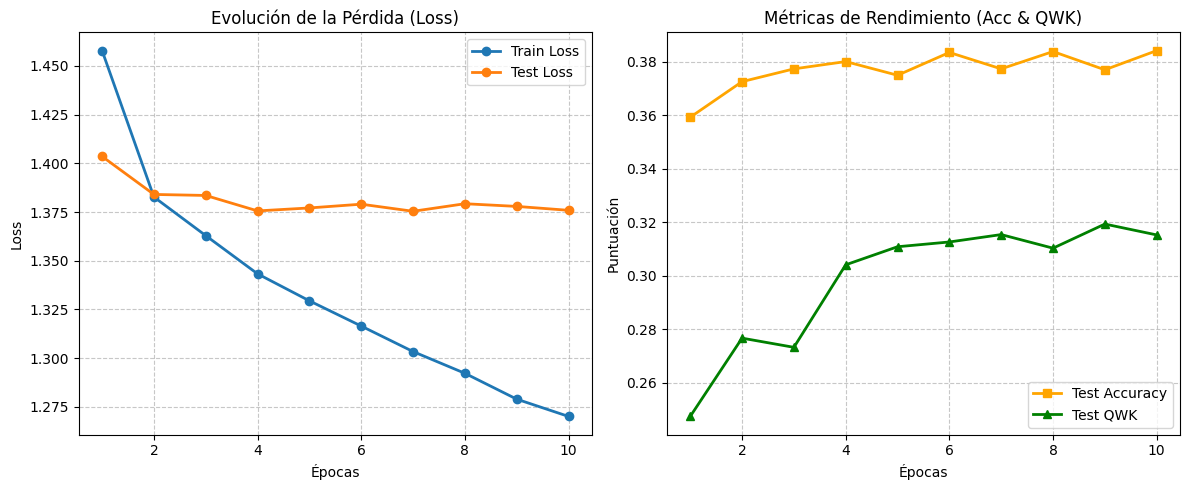

In [ ]:
epochs = range(1, 11)

plt.figure(figsize=(12, 5))

# 1. Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, history['test_loss'], label='Test Loss', marker='o', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfica de Métricas (Acc & QWK)
plt.subplot(1, 2, 2)
plt.plot(epochs, history['test_acc'], label='Test Accuracy', marker='s', color='orange', linewidth=2)
plt.plot(epochs, history['test_qwk'], label='Test QWK', marker='^', color='green', linewidth=2)
plt.title('Métricas de Rendimiento (Acc & QWK)')
plt.xlabel('Épocas')
plt.ylabel('Puntuación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

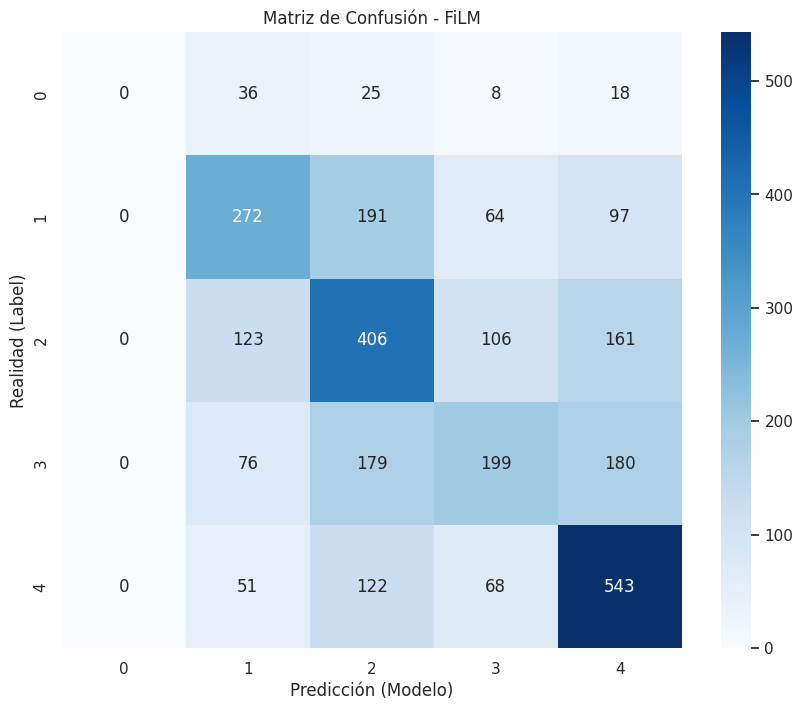

In [ ]:
pet_film_model = PetFiLMModel(num_tabular_features=num_features)
# 3. Cargamos los pesos desde tu Drive
weights_path = f"models/film_weights.pth"
state_dict = torch.load(weights_path, map_location=CONFIG["device"])

# 4. Inyectamos los pesos en el modelo
pet_film_model.load_state_dict(state_dict)
pet_film_model.to(CONFIG["device"])
pet_film_model.eval() # Modo evaluación (importante para Dropout/Batchnorm)

# 1. Ponemos el modelo en modo evaluación
y_true_film_classifier = []
y_pred_film_classifier = []

# 2. Recorremos el val_loader para obtener las predicciones finales
with torch.no_grad():
    for images, tabular, labels in tqdm(test_loader):
        images = images.to(CONFIG["device"])
        tabular = tabular.to(CONFIG["device"])
        outputs = pet_film_model(images, tabular)
        _, preds = torch.max(outputs, 1)

        y_true_film_classifier.extend(labels.numpy())
        y_pred_film_classifier.extend(preds.cpu().numpy())
# 3. Calculamos la matriz de confusión
cm = confusion_matrix(y_true_film_classifier, y_pred_film_classifier)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])

plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Label)')
plt.title('Matriz de Confusión - Bloque A (EfficientNet)')
plt.show()

Después de analizar los modelos híbridos para un enfoque de clasificación, se concluyen en que los resultados se podrían mejorar pero no explorando en nuevas arquitecturas, si no cambiando el planteamiento del problema.  Los modelos de clasificación estándar tratan las clases como independientes, penalizando de igual forma una predicción de 1 cuando la realidad es 0, que una predicción de 4 cuando la realidad es 0. Sin embargo al tratar el problema como una regresión,captura la magnitud del error, alineándose matemáticamente con la métrica de evaluación Quadratic Weighted Kappa (QWK), que penaliza cuadráticamente las discrepancias entre predicción y realidad. Este enfoque puede permitir al modelo aprender la continuidad de la adoptabilidad, mejorando la capacidad de generalización.

### Bloque C: Modelos Híbridos (Enfoque de Regresión)

Usamos la misma lógica híbrida del bloque anterior, pero ahora tratamos el problema como una **regresión**. Esto nos permitirá penalizar más los errores para máximizar el QWK 
En lugar de encasillar los datos en categorías, buscamos predecir valores exactos para luego aplicar umbrales.

#### Early Fusion Regression

##### Extracción de características usando CNN

Se extrajeron las características usando CNN en el apartado de clasificación. Obviamos su carga para este apartado.

##### Entrenamiento Modelos Tabulares: Random Forest

Para tratar correctamente el dataset como un problema de regresión se deben calcular los umbrales que determinan la clasificación de cada muestra. Para ello se ha realizado una función que optimiza estos coeficientes según el valor del QWK para el conjunto de validación. De nuevo puede existir una disminución de generalización del modelo para tratar muestras individiduales en el conjunto de test

In [ ]:
class OptimizedRounder(object):
    def __init__(self): self.coef_ = 0
    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]: X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]: X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]: X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]: X_p[i] = 3
            else: X_p[i] = 4
        ll = cohen_kappa_score(y, X_p, weights='quadratic')
        return -ll
    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')
    def predict(self, X, coef):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]: X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]: X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]: X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]: X_p[i] = 3
            else: X_p[i] = 4
        return X_p
    def coefficients(self): return self.coef_['x']

print("Entrenando Random Forest Regressor...")
rf_regressor_ef = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=5, random_state=CONFIG['seed'], n_jobs=-1)
rf_regressor_ef.fit(X_train_full, y_train_tab)
val_preds_rf_raw = rf_regressor_ef.predict(X_val_tab)

print("Ajustando Rounder RF...")
opt_rf = OptimizedRounder()
opt_rf.fit(val_preds_rf_raw, y_val_tab)
coef_rf = opt_rf.coefficients()
print(f"Cortes RF: {coef_rf}")

Entrenando Random Forest Regressor...
Ajustando Rounder RF...
Cortes RF: [0.52013325, 1.73570576, 2.40191319, 2.74369204]


In [ ]:
# Representación de los cortes optimizados y las distribuciones de clases

print("Visualizando cortes para Fusión CNN + Random Forest...")
visualize_optimized_thresholds(y_val_tab, val_fusion_rf, coef_rf, model_name="Fusión CNN + RF (Validación)")

##### Evaluación de los modelos en el conjunto de Test

--- Evaluando Random Forest ---

=== RESULTADOS QWK ===
RF  (Regresor): 0.2614
RF  (Clasificador): 0.2251


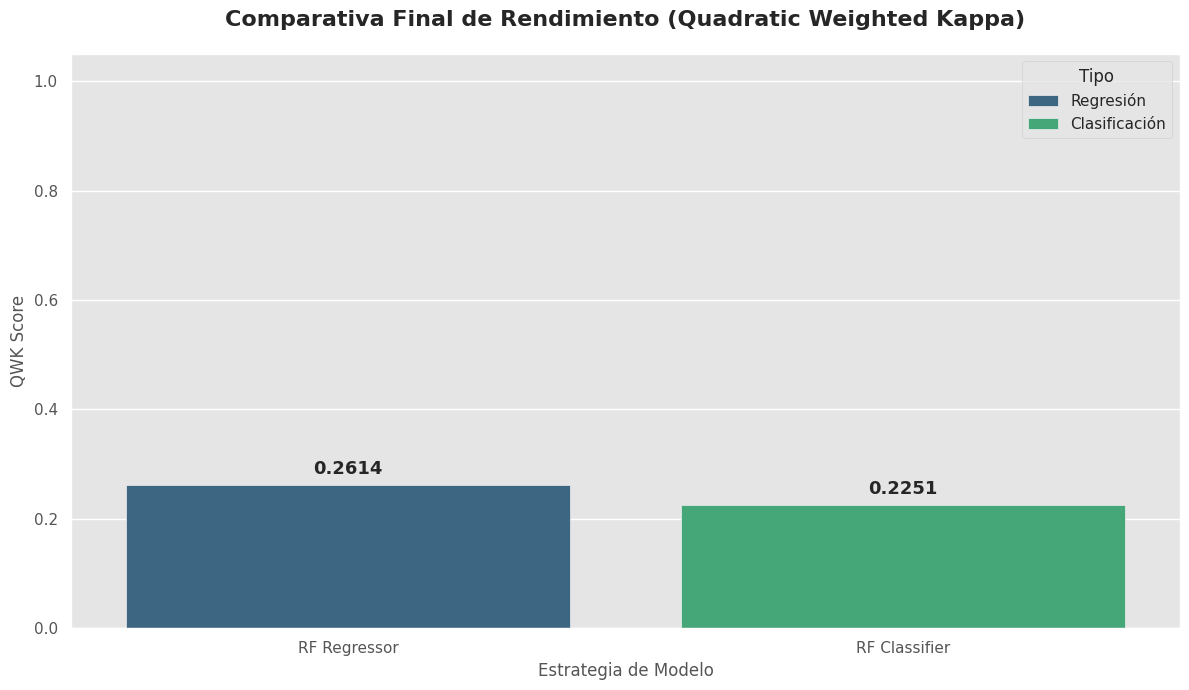

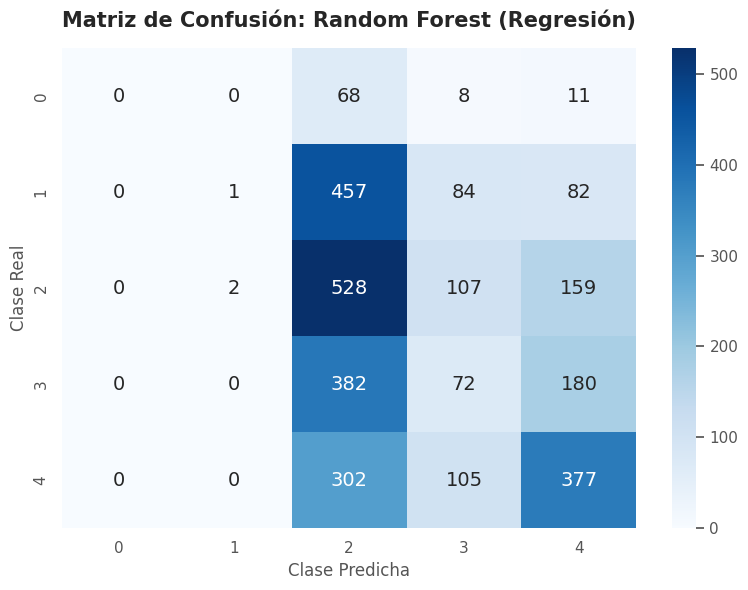

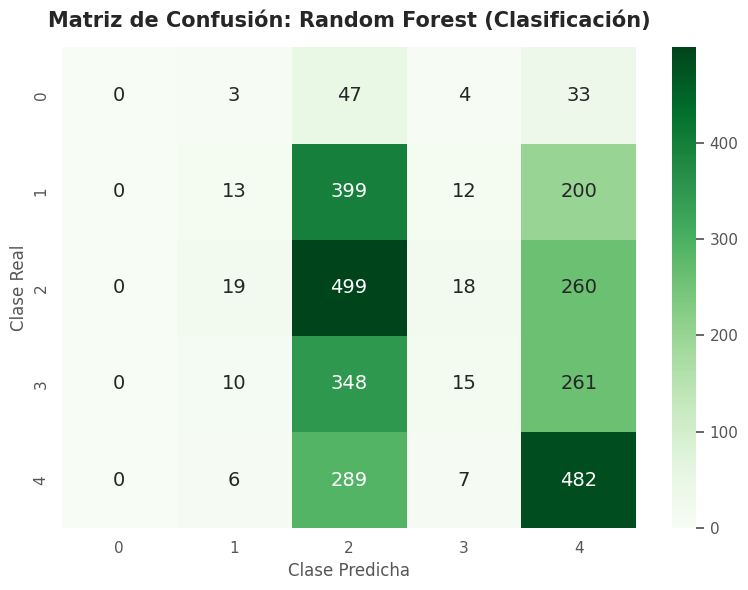

In [ ]:
# --- 1. GENERACIÓN DE PREDICCIONES EN TEST ---

print("--- Evaluando Random Forest ---")
# RF Regression
test_preds_rf_raw = rf_regressor_ef.predict(X_test_full)
test_preds_rf_reg = opt_rf.predict(test_preds_rf_raw, coef_rf).astype(int)
qwk_rf_reg = cohen_kappa_score(y_test_tab, test_preds_rf_reg, weights='quadratic')

# RF Classification
test_preds_rf = rf_classifier_ef.predict(X_test_full)
qwk_rf = cohen_kappa_score(y_test_tab, test_preds_rf, weights='quadratic')

# Imprimir Resultados Numéricos
print("\n=== RESULTADOS QWK ===")
print(f"RF  (Regresor): {qwk_rf_reg:.4f}")
print(f"RF  (Clasificador): {qwk_rf:.4f}")

# Configuración de estilo
plt.style.use('ggplot')

# ==========================================
# FIGURA 1: COMPARATIVA DE QWK (Barras)
# ==========================================
plt.figure(figsize=(12, 7))

# Preparar datos
results_data = {
    'Modelo': ['RF Regressor', 'RF Classifier'],
    'QWK Score': [qwk_rf_reg, qwk_rf],
    'Tipo': ['Regresión', 'Clasificación']
}
df_res = pd.DataFrame(results_data)

# Dibujar
ax = sns.barplot(x='Modelo', y='QWK Score', data=df_res, hue='Tipo', palette='viridis', dodge=False)

# Títulos y Etiquetas
plt.title('Comparativa Final de Rendimiento (Quadratic Weighted Kappa)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('QWK Score', fontsize=12)
plt.xlabel('Estrategia de Modelo', fontsize=12)
plt.ylim(0, 1.05) # Un poco de margen arriba

# Poner el número exacto encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show() # Muestra la gráfica de barras sola


# ==========================================
# FIGURAS 2-5: MATRICES DE CONFUSIÓN (Individuales)
# ==========================================

# Lista de configuración para iterar
matrices_info = [
    (test_preds_rf_reg, "Random Forest (Regresión)", "Blues"),
    (test_preds_rf, "Random Forest (Clasificación)", "Greens")
]

for preds, title, color_map in matrices_info:
    # Crear una figura nueva para cada iteración
    plt.figure(figsize=(8, 6))
    
    # Calcular matriz
    cm = confusion_matrix(y_test_tab, preds)
    
    # Dibujar Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, cbar=True, annot_kws={"size": 14})
    
    # Títulos y etiquetas
    plt.title(f'Matriz de Confusión: {title}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Clase Predicha', fontsize=12)
    plt.ylabel('Clase Real', fontsize=12)
    
    plt.tight_layout()
    plt.show() # Muestra cada matriz por separado

Tal y como habíamos predicho anteriormente las clases 2 y 4 son las más representadas sin embargo la clase 0,1 y 3 el modelo no es capaz de determinarlas correctamente

Analizando los resultados obtenidos en regresión podemos ver que la mejoría con la clasificación es notable aumentando un 17% los resultados. De nuevo tal y como se vio anteriormente, sigue sin ser bueno ya que no supera al modelo de Random Forest base que se entrenó en el incio. Esto concluye con que la fusión temprana para este conjunto de datos no es adecuada. Independientemente del enfoque la adición masiva de características provoca una pérdida de información relevante en el dataset

Gracias a los resultados en la fusión temprana se ve que es necesario seguir haciendo un recorrido por las demás arquitecturas ya que las que son más adecuadas van a conseguir mejorar el modelo para el proyecto planteado como un problema de clasificación

#### Late Fusion Regression

Para no entrenar de nuevo una CNN adaptada a regresión, en este bloque de código se realiza la inferencia final del modelo CNN, transformando el problema de clasificación en uno de regresión.

Primero se calculan las probabilidades teniendo un vector que suman 1 aplicando softmax, por tanto la salida corresponde con la probabilidad de pertenecer a cada una de las clases. Pero en lugar de quedarnos con la clase más probable se aplica esperanza matemática.

$$Score = \sum_{i=0}^{4} (Probabilidad_i \times Clase_i)$$

En este caso el modelo obtiene un valor continuo que representa mejor la realidad de los datos, es decir que un animal si se adopta a los 80 días la probabilidad de pertenencia a la clase 4 puede ser realmente alta haciendo al modelo elegir clase 4 sin embargo en este caso mantenemos el valor continuo para realizar el corte de umbrales como se hizo anteriormente y posteriormente la media ponderada para calcular finalmente la clase a la que pertenece cada muestra, suavizando el error en la predicción final.


##### Carga CNN EfficientNet

In [ ]:
# Función para obtener probabilidades (Inferencia)
def get_probs(loader, model):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for imgs, _, _ in tqdm(loader, desc="Inferencia CNN"):
            imgs = imgs.to(CONFIG["device"])
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs)

# Obtener predicciones (Probabilidades)
probs_cnn_val = get_probs(val_loader, efficientB0_trained_model)
probs_cnn_test = get_probs(test_loader, efficientB0_trained_model)

# --- TRANSFORMACIÓN A REGRESIÓN (Expectation) ---
# Convertimos probabilidades (5 clases) a un valor continuo [0-4]
def get_expected_score(probs):
    # Score = 0*p0 + 1*p1 + ... + 4*p4
    return np.sum(probs * np.arange(5), axis=1)

print("Transformando salidas CNN a valores continuos...")
scores_cnn_val = get_expected_score(probs_cnn_val)
scores_cnn_test = get_expected_score(probs_cnn_test)
print(f"CNN Val Scores Range: {scores_cnn_val.min():.2f} - {scores_cnn_val.max():.2f}")

Transformando salidas CNN a valores continuos...
CNN Val Scores Range: 1.02 - 3.46


##### Modelos Tabulares: Random Forest

En este caso si es necesario entrenar un nuevo modelo, el Random Forest de regresión para poder obtener las predicciones y realizar la posterior fusión tardía junto a la CNN calculada

In [112]:
# --- MODELOS TABULARES (REGRESIÓN) ---
# 1. Random Forest Regressor
print("Entrenando Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tab, y_train_tab)

scores_rf_val = rf_model.predict(X_val_tab)
scores_rf_test = rf_model.predict(X_test_tab)
print("RF Val RMSE:", np.sqrt(mean_squared_error(y_val_tab, scores_rf_val)))

Entrenando Random Forest Regressor...
RF Val RMSE: 1.0932018040390592


##### Optimización de la fusión tardía

In [ ]:
# --- Optimización de Fusión (Pesos) ---
# Objetivo: Maximizar QWK después de redondear (o minimizar RMSE)
# Para simplificar y hacerlo rápido, optimizaremos los pesos minimizando RMSE primero,
# y LUEGO encontraremos los cortes óptimos. Esto es más estable.

def fusion_rmse(weights, p1, p2, y_true):
    w1, w2 = weights
    preds = w1*p1 + w2*p2
    return np.sqrt(mean_squared_error(y_true, preds))

cons = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1), (0, 1)]
initial_weights = [0.5, 0.5]

# 1. CNN + RF
print("\n--- Optimización CNN + RF ---")
res_rf = minimize(fusion_rmse, initial_weights, args=(scores_cnn_val, scores_rf_val, y_val_tab), 
                  bounds=bounds, constraints=cons)
w_cnn_rf = res_rf.x
print(f"Pesos (RMSE min): CNN={w_cnn_rf[0]:.3f}, RF={w_cnn_rf[1]:.3f}")

# Generar Scores Fusión
val_fusion_rf = w_cnn_rf[0]*scores_cnn_val + w_cnn_rf[1]*scores_rf_val

# Encontrar Cortes Óptimos
rounder_rf = OptimizedRounder()
rounder_rf.fit(val_fusion_rf, y_val_tab)
coef_rf = rounder_rf.coefficients()
print("Cortes Óptimos (CNN+RF):", coef_rf)


def visualize_optimized_thresholds(y_true, y_pred_continuous, coefficients, model_name="Modelo"):
    """
    Visualiza la distribución de las predicciones continuas para cada clase real
    y dibuja las líneas de corte optimizadas.
    """
    plt.figure(figsize=(12, 6))
    
    # 1. Dibujar las distribuciones (densidad) de cada clase real
    # Iteramos por las clases reales (0 a 4)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i in range(5):
        # Seleccionamos las predicciones que corresponden a la clase real 'i'
        subset = y_pred_continuous[y_true == i]
        
        # Si hay datos para esa clase, dibujamos su densidad
        if len(subset) > 1:
            sns.kdeplot(subset, label=f'Clase Real {i}', fill=True, alpha=0.3, color=colors[i], linewidth=2)
        elif len(subset) == 1:
            plt.axvline(subset[0], color=colors[i], label=f'Clase Real {i} (1 muestra)', alpha=0.5)

    # 2. Dibujar los cortes (thresholds) optimizados
    for idx, coef in enumerate(coefficients):
        plt.axvline(coef, color='black', linestyle='--', linewidth=2, alpha=0.8)
        plt.text(coef, plt.ylim()[1]*0.95, f'Corte {idx}\n{coef:.2f}', 
                 horizontalalignment='center', color='black', fontweight='bold', backgroundcolor='white')

    # 3. Colorear el fondo para indicar las zonas de predicción
    # Zona 0 (< Corte 0)
    ymin, ymax = plt.ylim()
    plt.axvspan(min(y_pred_continuous.min(), coefficients[0]-0.5), coefficients[0], color=colors[0], alpha=0.05)
    # Zonas intermedias
    for i in range(len(coefficients)-1):
        plt.axvspan(coefficients[i], coefficients[i+1], color=colors[i+1], alpha=0.05)
    # Zona 4 (> Corte 3)
    plt.axvspan(coefficients[-1], max(y_pred_continuous.max(), coefficients[-1]+0.5), color=colors[4], alpha=0.05)

    plt.title(f'Optimización de Cortes (Thresholds) - {model_name}', fontsize=14)
    plt.xlabel('Predicción Continua (Regression Output)')
    plt.ylabel('Densidad')
    plt.legend(title='Ground Truth')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


--- Optimización CNN + RF ---
Pesos (RMSE min): CNN=0.249, RF=0.751


Cortes Óptimos (CNN+RF): [0.57597664 2.0077394  2.58312657 1.51598498]


Visualizando cortes para Fusión CNN + Random Forest...


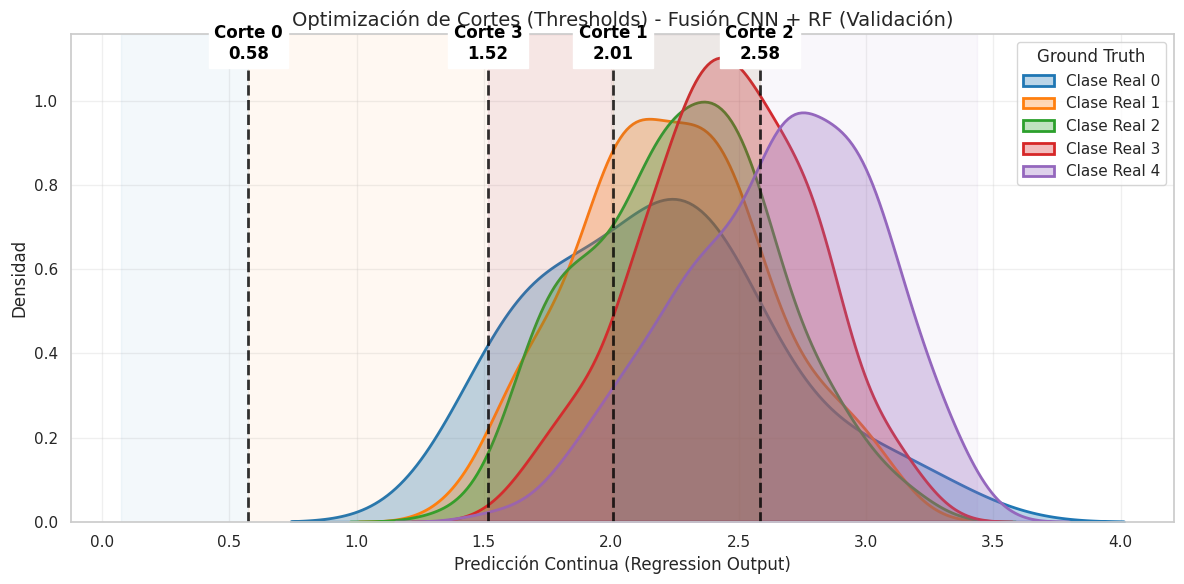

In [133]:
# Llamamos a tu función para ver cómo corta el modelo FUSIONADO
# Usamos datos de VALIDACIÓN porque ahí es donde se calcularon los cortes

print("Visualizando cortes para Fusión CNN + Random Forest...")
visualize_optimized_thresholds(y_val_tab, val_fusion_rf, coef_rf, model_name="Fusión CNN + RF (Validación)")

Con estos resultados podemos observar dos cosas diferentes. 

- Los pesos que asocia al Random Forest son mucho mayor que los que se le asocia a la CNN (0.75,0.25), el modelo tabular en este caso sigue siendo muy importante para el modelo hibrído y para la obtención del mejor QWK posible. De nuevo al ser valores obtenidos en validación pueden ser adecuado, pero no los mejores para la generalzación en cualquier caso
- Por otro lado la distribución de clases es realmente compleja por tanto la definición de umbrales es un proceso complejo, a pesar de ellos estos valores se optimizan para el conujnto de validación procurando conseguir los mejores valores posibles en el conjunto de test

##### Evaluación en el conjunto de Test

QWK CNN (Ref): 0.1587
QWK RF Reg:    0.3775
QWK Fusion RF: 0.4030


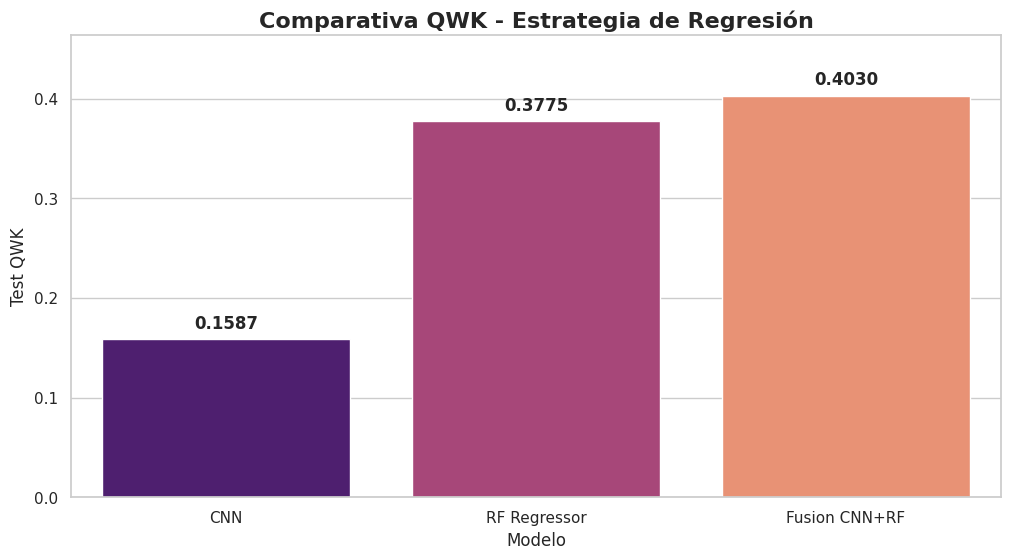

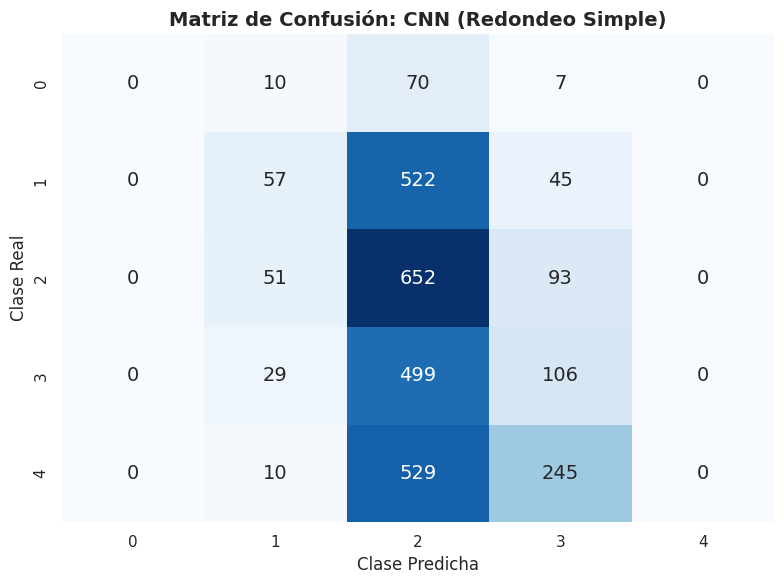

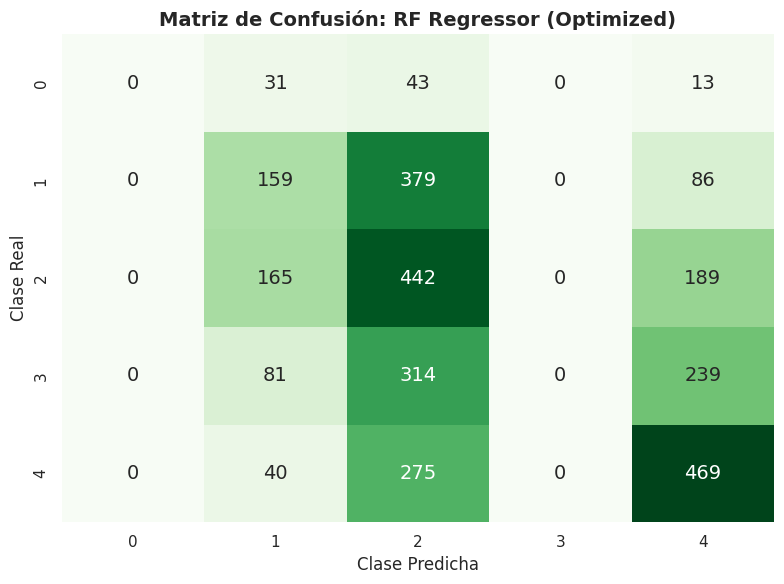

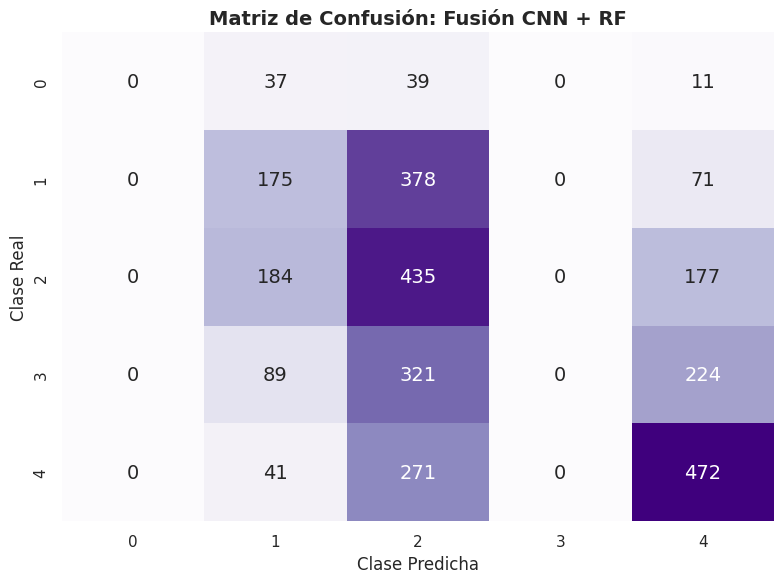

In [134]:
# --- 1. APLICAR FUSIÓN Y CORTES AL TEST SET ---

# A) CNN Individual (Asumiendo que scores_cnn_test es continuo)
# Si no tienes un rounder específico para CNN, usamos cortes estándar o redondeo simple
# Aquí usaremos el rounder optimizado del RF como aproximación o redondeo directo
preds_cnn_test = np.rint(scores_cnn_test).astype(int) # Redondeo simple 
preds_cnn_test = np.clip(preds_cnn_test, 0, 4)      # Asegurar rango 0-4

# B) Random Forest (Regresión)
# Usamos el rounder optimizado específico para RF
val_preds_rf_raw = rf_model.predict(X_val_tab) # Necesario para ajustar el rounder si no se hizo
opt_rf_only = OptimizedRounder()
opt_rf_only.fit(val_preds_rf_raw, y_val_tab)
coef_rf_only = opt_rf_only.coefficients()

scores_rf_test = rf_model.predict(X_test_tab)
preds_rf_test = opt_rf_only.predict(scores_rf_test, coef_rf_only).astype(int)

# D) Fusión CNN + RF (Usando pesos y cortes optimizados previamente)
test_fusion_rf_raw = w_cnn_rf[0] * scores_cnn_test + w_cnn_rf[1] * scores_rf_test
preds_fusion_rf = rounder_rf.predict(test_fusion_rf_raw, coef_rf).astype(int)

# --- CALCULAR QWK ---
qwk_cnn = cohen_kappa_score(y_test_tab, preds_cnn_test, weights='quadratic')
qwk_rf = cohen_kappa_score(y_test_tab, preds_rf_test, weights='quadratic')
qwk_fus_rf = cohen_kappa_score(y_test_tab, preds_fusion_rf, weights='quadratic')

print(f"QWK CNN (Ref): {qwk_cnn:.4f}")
print(f"QWK RF Reg:    {qwk_rf:.4f}")
print(f"QWK Fusion RF: {qwk_fus_rf:.4f}")



# --- COMPARATIVA DE BARRAS ---
results_reg = {
    'Modelo': ['CNN', 'RF Regressor', 'Fusion CNN+RF'],
    'Test QWK': [qwk_cnn, qwk_rf, qwk_fus_rf]
}
df_res_reg = pd.DataFrame(results_reg)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Modelo', y='Test QWK', data=df_res_reg, palette='magma')
plt.title('Comparativa QWK - Estrategia de Regresión', fontsize=16, fontweight='bold')
plt.ylim(0, max(df_res_reg['Test QWK']) * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=12, fontweight='bold')
plt.show()

# --- MATRICES DE CONFUSIÓN (INDIVIDUALES) ---
matrices_config = [
    (preds_cnn_test, "CNN (Redondeo Simple)", "Blues"),
    (preds_rf_test, "RF Regressor (Optimized)", "Greens"),
    (preds_fusion_rf, "Fusión CNN + RF", "Purples")
]

for preds, title, cmap in matrices_config:
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test_tab, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, annot_kws={"size": 14})
    plt.title(f'Matriz de Confusión: {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Clase Predicha')
    plt.ylabel('Clase Real')
    plt.tight_layout()
    plt.show()

Las resultados obtenidos en la fusión tardía son realmente buenos. Por un lado el modelo de la CNN unimodal ha empeorado notablemente su rendimiento sin embargo, la mejoría del apartado tabular ha supuesto que el modelo híbrido mejore aún más el rendimiento llegando a obtener valores de QWK del 40%

De nuevo la clase 0 debido a la importancia que recibe el modelo tabular no se ve representada, al igual que la clase 3 debido a la disposición de los umbrales. Esta conclusión podría haber sido interceptada desde antes donde los umbrales definían a la clase 3 en un pequeño umbral entre la clase 0 y la clase 1. El modelo ha determinado que eliminando dos clases consigue mejorar mucho las métricas, pasando de un problema de clasificación de 5 clases a un problema de clasficación enfocado para regresión con solo 3 clases. 

En este dataset en concreto, realmente la velocidad de adopción no es un aspecto crítico, por ejemplo como la salud de un paciente, donde el F1-score particular de cada una de las clases es realmente importante. Por tanto consideramos que este es el mejor resultado del QWK posible obtenido. Y en cuanto a la finalidad del proyecto, realizar análisis de comparación entre modelos unimodales y multimodales, si se ve afectado ya que el enfoque de regresión para este problema resulta ser interesante para le mejora de métricas finales.

#### Feature-wise Linear Modulation (FiLM) Versión Regresiva

In [ ]:
class PetFiLMModelRegression(nn.Module):
    def __init__(self, num_tabular_features, num_classes=5):
        super(PetFiLMModelRegression, self).__init__()
        
        # 1. VISUAL BACKBONE
        # Cargamos EfficientNet pero le quitamos el clasificador y el pooling final
        base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        self.features_extractor = base_model.features
        
        # Obtenemos dinámicamente el número de canales (1280 para B0)
        # Lo hacemos pasando un tensor dummy
        dummy_in = torch.randn(1, 3, 224, 224)
        dummy_out = self.features_extractor(dummy_in)
        self.num_channels = dummy_out.shape[1]
        
        # 2. TABULAR GENERATOR
        self.film_generator = TabularGenerator(num_tabular_features, self.num_channels)
        
        # 3. FILM LAYER
        self.film_layer = FiLMLayer()
        
        # 4. FINAL CLASSIFIER
        # Después del FiLM haremos un Global Average Pooling, así que entra num_channels
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.num_channels, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
        
        # Global Average Pooling layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, img, tab):
        # 1. Extraer características visuales (mapas espaciales)
        # Shape: [Batch, 1280, 7, 7]
        visual_map = self.features_extractor(img)
        
        # 2. Generar parámetros FiLM desde la tabla
        # Shapes: [Batch, 1280] cada uno
        gammas, betas = self.film_generator(tab)
        
        # 3. Aplicar Modulación FiLM
        # La tabla "colorea" los mapas de características
        x = self.film_layer(visual_map, gammas, betas)
        
        # 4. Pooling y Clasificación final
        x = self.avgpool(x)        # [Batch, 1280, 1, 1]
        x = torch.flatten(x, 1)    # [Batch, 1280]
        out = self.classifier(x)
        
        return out

In [ ]:
# --- 3. INSTANCIAR MODELO FiLM ---
print(f"Iniciando modelo FiLM con {num_features} features tabulares...")
# 1. Instancias tu nuevo modelo FiLM
# Instanciar modelo
model = PetFiLMModelRegression(num_tabular_features=num_features)

# --- PASO CRUCIAL PARA LA VELOCIDAD ---
# Congelamos toda la EfficientNet (el extractor de características)
for param in model.features_extractor.parameters():
    param.requires_grad = False

# Dejamos ABIERTOS los pesos de lo que sí queremos que aprenda:
# 1. El DJ (quien genera los parámetros FiLM desde la tabla)
for param in model.film_generator.parameters():
    param.requires_grad = True

# 2. El Clasificador (quien toma la decisión final)
for param in model.classifier.parameters():
    param.requires_grad = True
# ---------------------------------------

# Al optimizador solo le pasamos lo que tiene gradiente
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=5e-5
)

criterion = nn.MSELoss()

# ¡A VOLAR!
model_trained, history = train_film_model(model, train_loader, val_loader, test_loader, criterion, optimizer, num_epochs=10, is_regression=True)

Iniciando modelo FiLM con 75 features tabulares...


Epoch 1/10 [Train]: 100%|██████████| 330/330 [21:29<00:00,  3.91s/it, loss=1.7628]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 1:
   > Umbrales (Val): [0.506 1.506 2.394 3.55 ]
   > Train Loss: 2.1001 | Val Loss: 1.4896
   > Test Loss:  1.4597  | Test Acc: 0.2869 | Test QWK: 0.1761
------------------------------------------------------------


Epoch 2/10 [Train]: 100%|██████████| 330/330 [20:51<00:00,  3.79s/it, loss=1.8052]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 2:
   > Umbrales (Val): [0.526 1.553 2.522 3.284]
   > Train Loss: 1.3797 | Val Loss: 1.3083
   > Test Loss:  1.2840  | Test Acc: 0.2979 | Test QWK: 0.2153
------------------------------------------------------------


Epoch 3/10 [Train]: 100%|██████████| 330/330 [25:02<00:00,  4.55s/it, loss=0.8076] 
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 3:
   > Umbrales (Val): [0.529 1.84  2.321 2.704]
   > Train Loss: 1.2688 | Val Loss: 1.2623
   > Test Loss:  1.2606  | Test Acc: 0.3381 | Test QWK: 0.2896
------------------------------------------------------------


Epoch 4/10 [Train]: 100%|██████████| 330/330 [16:17<00:00,  2.96s/it, loss=0.8443]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 4:
   > Umbrales (Val): [0.572 1.907 2.347 2.981]
   > Train Loss: 1.2248 | Val Loss: 1.2619
   > Test Loss:  1.2601  | Test Acc: 0.3228 | Test QWK: 0.2985
------------------------------------------------------------


Epoch 5/10 [Train]: 100%|██████████| 330/330 [24:53<00:00,  4.52s/it, loss=1.0711] 
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 5:
   > Umbrales (Val): [0.56  1.757 2.327 2.769]
   > Train Loss: 1.1891 | Val Loss: 1.2551
   > Test Loss:  1.2606  | Test Acc: 0.3381 | Test QWK: 0.3065
------------------------------------------------------------


Epoch 6/10 [Train]: 100%|██████████| 330/330 [19:30<00:00,  3.55s/it, loss=1.6448]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 6:
   > Umbrales (Val): [0.526 1.827 2.256 2.836]
   > Train Loss: 1.1694 | Val Loss: 1.2246
   > Test Loss:  1.2282  | Test Acc: 0.3340 | Test QWK: 0.2960
------------------------------------------------------------


Epoch 7/10 [Train]: 100%|██████████| 330/330 [22:02<00:00,  4.01s/it, loss=1.0133]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 7:
   > Umbrales (Val): [0.544 1.774 2.378 2.69 ]
   > Train Loss: 1.1366 | Val Loss: 1.2269
   > Test Loss:  1.2504  | Test Acc: 0.3402 | Test QWK: 0.3022
------------------------------------------------------------


Epoch 8/10 [Train]: 100%|██████████| 330/330 [17:42<00:00,  3.22s/it, loss=0.8900]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 8:
   > Umbrales (Val): [0.513 1.618 2.311 3.693]
   > Train Loss: 1.1174 | Val Loss: 1.2679
   > Test Loss:  1.2693  | Test Acc: 0.2859 | Test QWK: 0.2349
------------------------------------------------------------


Epoch 9/10 [Train]: 100%|██████████| 330/330 [16:46<00:00,  3.05s/it, loss=0.9333]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 9:
   > Umbrales (Val): [0.524 1.828 2.481 2.92 ]
   > Train Loss: 1.1124 | Val Loss: 1.1994
   > Test Loss:  1.2170  | Test Acc: 0.3443 | Test QWK: 0.3064
------------------------------------------------------------


Epoch 10/10 [Train]: 100%|██████████| 330/330 [16:34<00:00,  3.01s/it, loss=0.7171]
/tmp/ipykernel_82312/1263391686.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_preds = np.array(test_preds).flatten().astype(int)


Epoch 10:
   > Umbrales (Val): [0.502 2.029 2.428 2.795]
   > Train Loss: 1.0903 | Val Loss: 1.1944
   > Test Loss:  1.2361  | Test Acc: 0.3576 | Test QWK: 0.3327
------------------------------------------------------------


In [ ]:
# 1. Definimos la ruta en tu Drive (puedes cambiar 'Mi Proyecto PetFinder' por el nombre que quieras)
save_path = CONFIG["save_path"]
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Guardamos el "State Dict" (es la forma más eficiente, guarda los pesos)
torch.save(model_trained.state_dict(), f'{save_path}/film_weights_regression.pth')

# 3. Opcional: Guardar también el historial para no perder las gráficas si se cierra la sesión

with open(f'{save_path}/history_film.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"Modelo y historial guardados con éxito en: {save_path}")

Modelo y historial guardados con éxito en: /home/alvaro/machine_learning/proyecto_final/dl_ml_muia/Dataset_petfinder


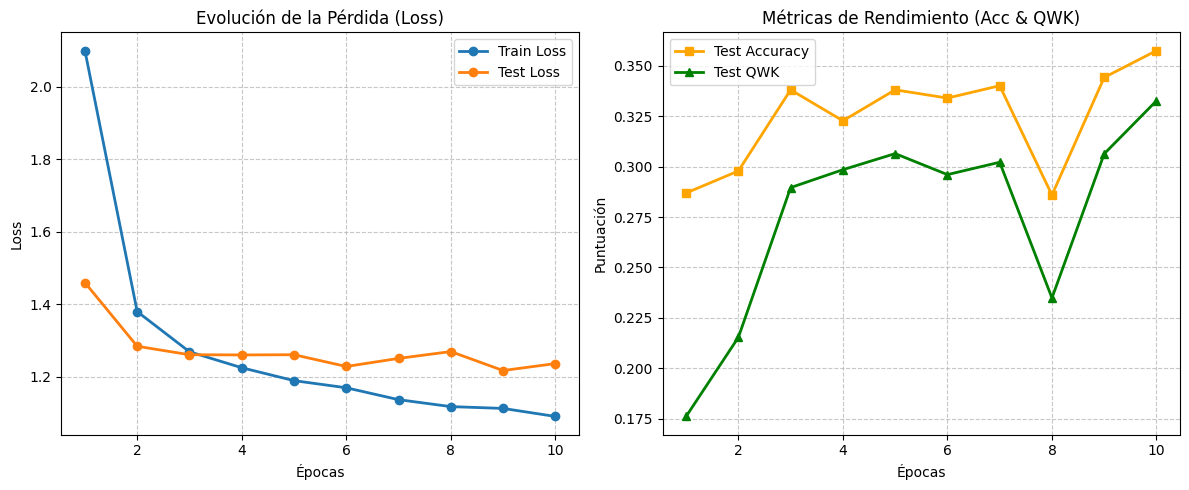

In [ ]:
epochs = range(1, 11)

plt.figure(figsize=(12, 5))

# 1. Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, history['test_loss'], label='Test Loss', marker='o', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Gráfica de Métricas (Acc & QWK)
plt.subplot(1, 2, 2)
plt.plot(epochs, history['test_acc'], label='Test Accuracy', marker='s', color='orange', linewidth=2)
plt.plot(epochs, history['test_qwk'], label='Test QWK', marker='^', color='green', linewidth=2)
plt.title('Métricas de Rendimiento (Acc & QWK)')
plt.xlabel('Épocas')
plt.ylabel('Puntuación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

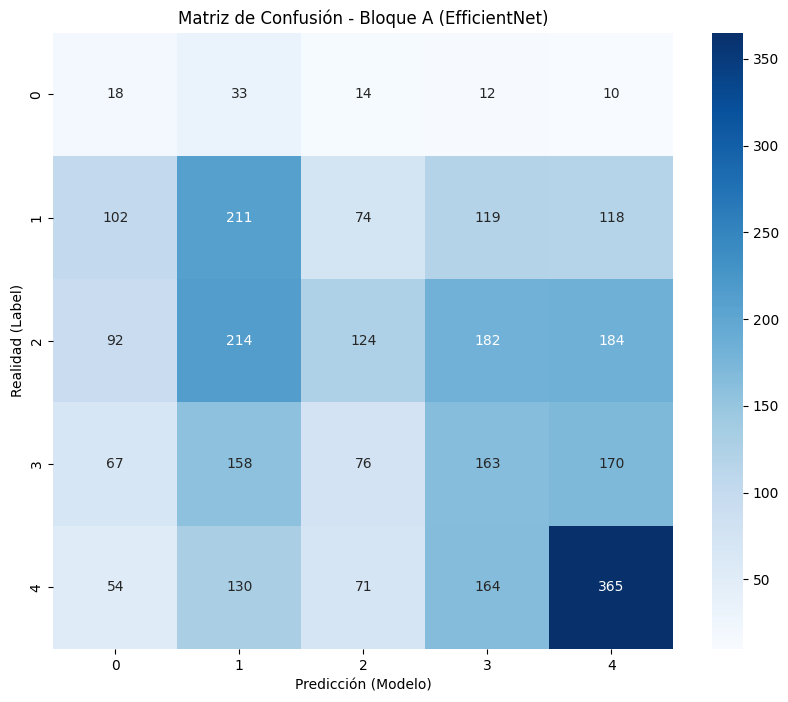

In [ ]:
pet_film_model = PetFiLMModel(num_tabular_features=num_features)
# 3. Cargamos los pesos desde tu Drive
weights_path = f"models/film_weights.pth"
state_dict = torch.load(weights_path, map_location=CONFIG["device"])

# 4. Inyectamos los pesos en el modelo
pet_film_model.load_state_dict(state_dict)
pet_film_model.to(CONFIG["device"])
pet_film_model.eval() # Modo evaluación (importante para Dropout/Batchnorm)

# 1. Ponemos el modelo en modo evaluación
y_true_film_classifier = []
y_pred_film_classifier = []

# 2. Recorremos el val_loader para obtener las predicciones finales
with torch.no_grad():
    for images, tabular, labels in tqdm(test_loader):
        images = images.to(CONFIG["device"])
        tabular = tabular.to(CONFIG["device"])
        outputs = pet_film_model(images, tabular)
        _, preds = torch.max(outputs, 1)

        y_true_film_classifier.extend(labels.numpy())
        y_pred_film_classifier.extend(preds.cpu().numpy())
# 3. Calculamos la matriz de confusión
cm = confusion_matrix(y_true_film_classifier, y_pred_film_classifier)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])

plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Label)')
plt.title('Matriz de Confusión - Bloque A (EfficientNet)')
plt.show()

## 4. Análisis de los Resultados

| Modelo | QWK |
| :--- | :---: |
| Solo Random Forest | 0.330 |
| Solo CNN | 0.256 |
| Fusión Temprana (Class) | 0.222 |
| Fusión Tardia (Class) | 0.365 |
| FiLM (Class) | 0.319 |
| Fusión Temprana (Regress) | 0.261 |
| Fusión Tardia (Regress) | 0.403 |
| FiLM (Regress) | 0.334 |

## Conclusión

###  Discusión Crítica a modo de resumen de los Resultados Finales

Tras la evaluación comparativa de las distintas estrategias de modelado, los resultados obtenidos arrojan conclusiones reveladoras sobre la naturaleza multimodal del *PetFinder Dataset*. A continuación, analizamos el comportamiento de cada arquitectura:

#### 1. Fusión Temprana (Early Fusion)
Esta estrategia ha mostrado un rendimiento inferior al esperado, situándose incluso por debajo del *baseline* tabular (Random Forest puro).
* **Diagnóstico:** La concatenación directa de vectores visuales (de alta dimensionalidad) con las características tabulares parece han introducido **ruido** en el modelo de Machine Learning clásico.
* **Justificación:** Al aumentar drásticamente el espacio de características con embeddings de imágenes que poseen una varianza compleja, los árboles de decisión (Random Forest) pierden eficiencia en la selección de los cortes óptimos, diluyendo la señal predictiva fuerte que poseen los metadatos originales. Además muchoas de las características importantes del modelo base pierden importancia debido a la gran cantidad de nuevas características de las imágenes
* **Posible Solución:** A pesar de realizar un Análisis de componentes principales (PCA) para disminuir la dimensionalidad de las características, la métrica elegida no presenta mejoría, parece que la importancia que procura aportar las imágenes sobrepasan la verdadera información importante de los datos tabulares

#### 2. Fusión Tardía (Late Fusion) - Mejor Modelo
El enfoque de ensamblado (*Ensemble*) ha resultado ser la estrategia ganadora, alcanzando el **QWK más alto** del experimento.
* **Sinergia de Modelos:** Al entrenar las ramas tabular y visual de forma independiente y promediar sus predicciones a posteriori, se permite que cada modelo se especialice en su dominio sin interferencias. Consiguiendo que las clases más difíciles de distinguir para cada modelo por separado se apoye del otro mejorando el resultado común.
* **Reducción de Varianza:** La mejora significativa sugiere que los errores cometidos por el modelo tabular y el modelo visual están **descorrelacionados**. Allí donde la imagen es ambigua, la tabla aporta certeza, y viceversa, logrando una predicción conjunta mucho más robusta.

#### 3. Arquitectura FiLM (Deep Learning Híbrido)
El modelo *End-to-End* basado en FiLM ha logrado superar a la CNN unimodal (Bloque A), aunque no ha alcanzado el rendimiento del Random Forest puro.
* **Mejora sobre la CNN:** El hecho de que FiLM supere al modelo de solo imágenes demuestra que el mecanismo de atención funciona: la red ha aprendido a utilizar los datos tabulares para rmodular y focalizar la extracción de características visuales.
* **Limitación Estructural:** La arquitectura FiLM utiliza la imagen como eje central (backbone) y la tabla como condicionante. Dado que en este dataset la información tabular tiene un peso predictivo mucho mayor que la visual (la raza y la edad pesan más que la foto), una arquitectura que prioriza el flujo visual parte con desventaja frente a los modelos basados puramente en árboles.

#### Enfoque de Regresión
Sin embargo a pesar de que la elección de una arquitectura adecuada es muy importante para obtener las mejores métricas, el enfoque que recibe el dataset tiene la misma relevancia. En este proyecto se observa como tratar este conjunto de datos como un problema de regresión hace que la métrica usada para el análsis del dataset mejore considerablemente.

### Conclusión General
El experimento confirma que, para este problema específico, la **información tabular es el predictor dominante**. Sin embargo, la integración inteligente de la visión de imágenes (especialmente mediante Fusión Tardía) aporta una mejora incremental valiosa, validando la hipótesis de que la multimodalidad permite capturar matices que escapan a los modelos unimodales.